# AMSS-NCKU-Python运行流程

这是一个AMSS-NCKU-Python的运行流程

## 1 预备操作 

### 设定AMSS-NCKU-Python输出界面的语言

In [1]:

##################################################################
## 程序即将开始，选择屏幕终端的输出语言
##################################################################

import logo
import main_program_function

## 输出本程序的 logo
logo.print_logo()

## 让用户选择一语言    
input_language = main_program_function.setting_language() 



 W     W     W  E E E E   L           C C C      O O O       M     M      E E E E          T T T T T    O O O   
  W   W W   W   E         L         C          O       O    M M   M M     E                    T      O       O 
  W   W W   W   E E E E   L         C          O       O   M   M M   M    E E E E              T      O       O 
   W W   W W    E         L         C          O       O   M   M M   M    E                    T      O       O 
    W     W     E E E E   L L L L     C C C      O O O    M     M     M   E E E E              T        O O O   


     A        M     M     S S S S   S S S S      N     N     C C C   K     K   U     U      P P P     Y      Y  
    A A      M M   M M    S         S            N N   N   C         K   K     U     U      P     P     Y   Y   
   A   A    M   M M   M   S S S S   S S S S  --  N  N  N   C         K K       U     U      P     P       Y     
  A A A A   M   M M   M         S         S      N   N N   C         K   K     U     U      P

### 输出AMSS-NCKU-Python的说明

In [2]:

##################################################################
## 输出本程序的说明
##################################################################

import print_information

if ( input_language == "Chinese" ):
    print_information.print_program_introduction_Chinese()
elif ( input_language == "English" ):
    print_information.print_program_introduction_English()




------------------------------------------------------------------------------------------

     数值相对论计算程序 AMSS-NCKU  

     原程序作者： 曹周键等 
     程序 Python 接口作者：小曲 

     AMSS-NCKU 是一个数值相对论程序  
     本程序用来对双黑洞合并过程进行数值模拟，通过数值求解爱因斯坦方程得到双黑洞合并过程中引力场随时间的演化，
 从而得到黑洞的轨迹和释放引力波的信息。

     在数值方法上，本程序用使用有限差分方法对双黑洞合并过程进行数值模拟。程序中可以选择的差分方法有：2 阶 
 差分、4 阶差分、6 阶差分、8 阶差分 
     程序中可以选择的微分方程为：BSSN 方程、Z4C 方程、BSSN 方程耦合标量场、BSSN 方程耦合电磁场 
     程序中可以选择的网格类型为：方形网格、最外层带球壳的 shell patch 网格 

     除此之外，本程序还实现了 CPU 和 GPU 的混合运算

------------------------------------------------------------------------------------------



## 2 设定AMSS-NCKU相关的参数 

### 设定相关的参数 

利用下面的魔术命令生成对应的 AMSS_NCKU_Input.py 

%%writefile AMSS_NCKU_Input.py

In [3]:
%%writefile AMSS_NCKU_Input.py

#################################################
## 这里包含了数值相对论所需要的输入
#################################################

import numpy  

#################################################
## 设置程序运行目录和计算资源
## Setting MPI processes and the output file directory
#################################################

File_directory   = "GW150914_test"                   ## 程序运行目录             output file directory
Output_directory = "binary_output"               ## 存放二进制数据的子目录     binary data file directory
                                                 ## The file directory name should not be too long
MPI_processes    = 6                             ## 想要调用的进程数目        number of mpi processes used in the simulation

GPU_Calculation  = "no"                          ## 是否开启 GPU 计算，可选 yes 或 no   Use GPU or not 
                                                 ## (prefer "no" in the current version, because the GPU part may have bugs when integrated in this Python interface)
CPU_Part         = 1.0
GPU_Part         = 0.0


#################################################
## 设置物理系统和程序计算方法
## Setting the physical system and numerical method
#################################################

Symmetry                 = "equatorial-symmetry"   ## Symmetry of System: choose equatorial-symmetry, no-symmetry, octant-symmetry
                                                   ## 注意：如果选择 octant-symmetry 最好使用固定网格计算，octant-symmetry 对移动网格有些 bug 
Equation_Class           = "BSSN"                  ## Evolution Equation: choose "BSSN", "BSSN-EScalar", "BSSN-EM", "Z4C" 
                                                   ##       BSSN 和 Z4C   适合于 GR 旋转黑洞的真空计算
                                                   ##       BSSN-EM      涉及 GR 带电黑洞的真空计算
                                                   ##       BSSN-EScalar 涉及到标量张量-F(R) 理论的计算，需要在后面设定额外参数
                                                   ## 注意：GPU 计算仅支持 BSSN      GPU calculation only supports "BSSN"
                                                   ## 这里选择 BSSN-EScalar，需要在后面设定 F(R) 理论的参数
                                                   ## If "BSSN-EScalar" is chosen, it is necessary to set other parameters below
Initial_Data_Method      = "Ansorg-TwoPuncture"    ## 设置求解数值相对论初值的方法
                                                   ## initial data method: choose "Ansorg-TwoPuncture", "Lousto-Analytical", "Cao-Analytical", "KerrSchild-Analytical"
                                                   ## 注意：当前 BSSN-EM 的计算不支持用解析公式 Lousto-Analytical、Cao-Analytical、KerrSchild-Analytical
                                                   ##       当前 BSSN-EScalar 的计算不支持用解析公式 Lousto-Analytical、Cao-Analytical、KerrSchild-Analytical
Time_Evolution_Method    = "runge-kutta-45"        ## 时间演化方法     time evolution method: choose "runge-kutta-45"
Finite_Diffenence_Method = "6th-order"             ## 有限差分方法     finite-difference method: choose "2nd-order", "4th-order", "6th-order", "8th-order"


#################################################
## 设置时间演化信息
## Setting the time evolutionary information
#################################################

Start_Evolution_Time     = 0.0                    ## 起始演化时间   start evolution time t0
Final_Evolution_Time     = 20.0                   ## 最终演化时间   final evolution time t1
Check_Time               = 100.0
Dump_Time                = 100.0                  ## 每隔一定时间间隔储存数据   time inteval dT for dumping binary data
D2_Dump_Time             = 100.0                  ## dump the ascii data for 2d surface after dT'
Analysis_Time            = 0.1                    ## dump the puncture position and GW psi4 after dT"
Evolution_Step_Number    = 10000000               ## 最大迭代次数       stop the calculation after the maximal step number
Courant_Factor           = 0.5                    ## Courant 因子（决定每一步时间演化的时间间隔）    Courant Factor
Dissipation              = 0.15                   ## 耗散因子                                                                                    Kreiss-Oliger Dissipation Strength


#################################################
## 设置AMR网格信息
## Setting the AME grid structure
#################################################

basic_grid_set    = "Patch"                          ## 设定网格类型，可选 Patch 和 Shell-Patch     grid structure: choose "Patch" or "Shell-Patch"
grid_center_set   = "Vertex"                         ## 网格中心设置，可选 Cell 和 Vertex           grid center: chose "Cell" or "Vertex"

grid_level        = 9                                ## 设置格点的总层数              total number of AMR grid levels
static_grid_level = 6                                ## 设置静态格点的层数            number of AMR static grid levels
moving_grid_level = grid_level - static_grid_level   ## 可移动格点的层数             number of AMR moving grid levels

analysis_level    = 0
refinement_level  = 4                                ## 从该层开始进行时间细化        time refinement start from this grid level

largest_box_xyz_max = [600.0, 600.0, 600.0]          ## 设置最外层格点的坐标最大值     scale of the largest box
                                                     ## not ne cess ary to be cubic for "Patch" grid s tructure
                                                     ## need to be a cubic box for "Shell-Patch" grid structure
## largest_box_xyz_min = - numpy.array(largest_box_xyz_max)  ## 设置最外层格点的坐标最小值
largest_box_xyz_min = [-600.0, -600.0, -600.0]

static_grid_number = 96                              ## 设置固定格点每一层每一维数的格点数目（这里对应的 x 轴格点数目，yz 轴格点自动调整）
                                                     ## grid points of each static AMR grid (in x direction)
                                                     ## (grid points in y and z directions are automatically adjusted)
moving_grid_number = 40                              ## 设置可移动格点每一层每一维数的格点数目               grid points of each moving AMR grid
shell_grid_number  = [32, 32, 100]                   ## 设置最外层球状网格（shell patch）的格点数目     grid points of Shell-Patch grid
                                                     ## 以 phi、theta、r 的顺序给定                                        in (phi, theta, r) direction
devide_factor      = 2.0                             ## 设置相邻两层网格分辨率的比例（不要轻易改变）
                                                     ## resolution between different grid levels dh0/dh1, only support 2.0 now

static_grid_type   = 'Linear'                        ## 设置固定格点的类型，可选 'Linear'      AMR static grid structure , only supports "Linear"
moving_grid_type   = 'Linear'                        ## 设置可移动格点的类型，可选 'Linear'    AMR moving grid structure , only supports "Linear"

quarter_sphere_number = 96                           ## 1/4 球面积分的格点数目
                                                     ## grid number of 1/4 s pher ical surface
                                                     ## (which is needed for evaluating the spherical surface integral)

#################################################

## 设置黑洞 puncture（穿刺法）的信息
## Setting the puncture information
#################################################

puncture_number       = 2                                     

position_BH           = numpy.zeros( (puncture_number, 3) )   
parameter_BH          = numpy.zeros( (puncture_number, 3) )   
dimensionless_spin_BH = numpy.zeros( (puncture_number, 3) )   
momentum_BH           = numpy.zeros( (puncture_number, 3) )   

puncture_data_set     = "Manually"                       ## 设置双星轨道坐标的方式，可选 Manually 和 Automatically-BBH
                                                         ## Method to give Puncture’s positions and momentum
                                                         ## choose "Manually" or "Automatically-BBH"
                                                         ## Prefer to choose "Manually", because "Automatically-BBH" is developing now

#---------------------------------------------

## 设置每个黑洞的参数 (M Q* a*)  
## black hole parameter (M Q* a*)
## 质量  无量纲电荷  无量纲自旋
parameter_BH[0] = [ 1.0,  0.0,  0.0 ]   
parameter_BH[1] = [ 1.0,  0.0,  0.0 ] 
## parameter_BH[2] = [ 0.5,  0.0,  0.0 ]   ## 多黑动手动添加
## 注意，如果求解数值相对论初值的方法选为 Ansorg-TwoPuncture ，第一个黑洞必须为质量较大的那个，且黑洞总质量会自动 rescale 为 M=1 （其它情况下必须手动 rescale）

## 设置每个黑洞的无量纲自旋
## dimensionless spin in each direction
## 无对称性时 ，需要手动给 3 个方向的自旋角动量
dimensionless_spin_BH[0] = [ 0.0,  0.0,  0.0 ]   
dimensionless_spin_BH[1] = [ 0.0,  0.0,  0.0 ]  
## dimensionless_spin_BH[2] = [ 0.0,  0.0,   0.0  ]  ## 多黑动手动添加

#---------------------------------------------

## 如果设置双星初始轨道坐标的方式选为 Automatically-BBH，只需要给定黑洞参数，偏心率，距离即可

#---------------------------------------------

## 这一步与初值求解中的 Ansorg-TwoPuncture 配合使用中需要注意的问题
## 用 Ansorg-TwoPuncture 求解初值，轨道坐标设置可以设置 Manually 和 Automatically-BBH 设置双星轨道坐标
## 但双星轨道坐标如果设置为 Manually 而不是 Automatically-BBH，则要细致设置 Puncture 的位置和动量取值，否则可能会使 TwoPuncture 程序无法正确读入输入而报错）

## initial orbital distance and ellipticity for BBHs system
## ( needed for "Automatically-BBH" case , not affect the "Manually" case )
Allow_PN_Evaluation = "yes"  ## 是否允许从更远的位置进行后牛顿演化，以提高计算精度
Distance_initial = 100.0
e0               = 0.0
Distance_final   = 10.0

## 注意，如果设置双星初始轨道坐标的方式选为 Automatically-BBH，则程序自动调整将较大质量黑洞放在 y 轴正向，将较小质量黑洞放在 y 轴负向
##       如果设置双星初始轨道坐标的方式选为 Manually，且则需要手动调整到 y 轴方向 
## use Brugmann's convention
##  -----0-----> y
##   -      +     

#---------------------------------------------

## 如果设置 puncture 初始轨道坐标的方式选为 Manually，还需要手动给定所有黑洞参数
## If puncture_data_set is chosen to be "Manually", it is necessary to set the position and momentum of each puncture manually

## 设置每个黑洞的初始位置     initial position for each puncture
position_BH[0]  = [  0.0, -3.0, 0.0 ]  
position_BH[1]  = [  0.0,  3.0, 0.0 ] 
## position_BH[2]  = [  0.0, 0.0, 0.0 ]  ## 多黑洞手动添加

## 设置每个黑洞的动量信息    initial mumentum for each puncture
## (needed for "Manually" case, does not affect the "Automatically-BBH" case)
momentum_BH[0]  = [ 0.0,  0.0,   0.0 ]
momentum_BH[1]  = [ 0.0,  0.0,   0.0 ]
## momentum_BH[2]  = [ 0.0,  0.0,  0.0 ]  ## 多黑洞手动添加

#---------------------------------------------


#################################################
## 设置引力波和探测器的相关信息
## Setting the gravitational wave information
#################################################

GW_L_max        = 4                      ## 引力波最大的 L    maximal L number in gravitational wave
GW_M_max        = 4                      ## 引力波最大的 M    maximal M number in gravitational wave
Detector_Number = 11                     ## 探测器的数目            number of dector
Detector_Rmin   = 50.0                   ## 最近探测器的距离   nearest dector distance
Detector_Rmax   = 150.0                  ## 最远探测器的距离   farest dector distance

#################################################


#################################################

## 设置表观视界的参数
## Setting the apprent horizon

AHF_Find       = "no"                    ## 是否开启表观视界计算，可选 yes 或 no

AHF_Find_Every = 24
AHF_Dump_Time  = 20.0

#################################################



#################################################

## 设置二进制画图相关信息

plot_binary_data_set         = "xy-xz-yz-plot"             ## 选择 "xy-plot", "xz-plot", "yz-plot", "xy-xz-yz-plot"
## plot_binary_data_type        = "Linear"                 ## 对哈密顿约束，TrK这些数据画图选择
                                                           ## 选择 "Linear", "Logarithmic"
                                                           ## 后续开发
plot_binary_data_level       = "All-Level"                 ## 选择 "All-level", "Single-level"
plot_binary_data_levelnumber = static_grid_level-1         ## 选择对哪个层来进行画图

#################################################


#################################################

## 标量-张量-f(R) 理论的一些参数
## 仅对 BSSN-EScalar 的计算有影响
## Other parameters (testing)
## Only influence the Equation_Class = "BSSN-EScalar" case

FR_a2     = 3.0        ## f(R) = R + a2 * R^2    
FR_l2     = 10000.0
FR_phi0   = 0.00005
FR_r0     = 120.0
FR_sigma0 = 8.0
FR_Choice = 2          ## Choice 1 2 3 4 5
                       ## 可选为 1 2 3 4 5
                       ## 1: phi(r) = phi0 * Exp(-(r-r0)**2/sigma0)  
                       ##    V(r)   = 0
                       ## 2: phi(r) =  phi0 * a2^2/(1+a2^2)  
                       ##    V(r)   = Exp(-8*Sqrt(PI/3)*phi(r)) * (1-Exp(4*Sqrt(PI/3)*phi(r)))**2 / (32*PI*a2)
                       ## 3: Schrodinger-Newton 系统给定的 phi(r) 
                       ##    V(r)   = Exp(-8*Sqrt(PI/3)*phi(r)) * (1-Exp(4*Sqrt(PI/3)*phi(r)))**2 / (32*PI*a2)
                       ## 4: phi(r) = phi0 * 0.5 * ( tanh((r+r0)/sigma0) - tanh((r-r0)/sigma0) )  
                       ##    V(r)   = 0
                       ## 5: phi(r) = phi0 * Exp(-(r-r0)**2/sigma)   
                       ##    V(r)   = 0


#################################################
## 其它选项，还在测试中
## 但不建议用户轻易改动这些选项
## Other parameters (testing)
## (please do not change if not necessary)
#################################################

boundary_choice = "BAM-choice"     ## 索莫菲边界条件设定，可选 "BAM-choice" 和 "Shibata-choice"
                                   ## Sommerfeld boundary condition : choose "BAM-choice" or "Shibata-choice" 
                                   ## 目前的版本定建议选为 "BAM-choice"          
                                   ## prefer "BAM-choice"

gauge_choice  = 0                  ## 规范条件选取
                                   ## 0: B^i gauge
                                   ## 1: David's puncture gauge
                                   ## 2: MB B^i gauge               ## 对Z4C和GPU计算好像有bug
                                   ## 3: RIT B^i gauge
                                   ## 4: MB beta gauge 
                                   ## 5: RIT beta gauge 
                                   ## 6: MGB1 B^i gauge
                                   ## 7: MGB2 B^i gauge
                                   ## 目前的版本建议选为 0 或 1
                                   ## prefer 0 or 1
                                   
tetrad_type  = 2                   ## tetradtype 
                                   ## 选取 0 1 2
                                   ## choose 0 1 2
                                   ## 目前的版本建议选为 2
                                   ## prefer 2
                
                                   ## 以下   v:r; u: phi; w: theta
                                   ##       v^a = (x,y,z)
                                   ## 0: orthonormal order: v,u,w
                                   ##    v^a = (x,y,z)   
                                   ##    m = (phi - i theta)/sqrt(2) 
                                   ##    following Frans, Eq.(8) of  PRD 75, 124018(2007)
                                   ## 1: orthonormal order: w,u,v
                                   ##    m = (theta + i phi)/sqrt(2) 
                                   ##    following Sperhake, Eq.(3.2) of  PRD 85, 124062(2012)    
                                   ## 2: orthonormal order: v,u,w
                                   ##    v_a = (x,y,z)
                                   ##    m = (phi - i theta)/sqrt(2) 
                                   ##    following Frans, Eq.(8) of  PRD 75, 124018(2007)


Overwriting AMSS_NCKU_Input.py


### 确认参数正确 

In [4]:

##################################################################
## 确认参数是正确的
##################################################################

## 屏幕输出程序开始运行前的提示
print_information.print_begin_program( input_language )


###############################
## 如果同意继续运算，则输入回车
###############################
## inputvalue = input()   ## 设定一个输入（回车），以便程序下一步运行         
## print()

###############################
## 上述操作针对用命令行运行 python
## Jupyter Notebook中不再需要上述暂停
###############################



 计算即将开始，请确认在 AMSS_NCKU_Input.py 中设置了正确的参数，按回车继续！！！  
 如果输入参数没有设置好，Ctrl+C 退出，调整 AMSS_NCKU_Input.py 中的输入参数！！！ 



## 3 根据设定的参数，生成AMSS-NCKU所需要的参数文件

### 导入在AMSS_NCKU_Input.py文件中设定的参数，并生成程序运行目录

In [5]:

##################################################################
## 生成文件目录，用来储存程序运行的数据
##################################################################

import AMSS_NCKU_Input as input_data  ## 导入参数文件
import os
import shutil


## 根据输入文件来设置文件目录
File_directory = os.path.join(input_data.File_directory)   

## 检查设定的输出目录是否存在，并根据用户的输入决定继续计算还是终止计算
main_program_function.continue_or_stop( File_directory, input_language )
        
## 如果文件目录已经存在，则去除它
shutil.rmtree(File_directory, ignore_errors=True)

## 创建文件夹
os.mkdir(File_directory)

## 复制 python 输入文件到程序运行目录
shutil.copy("AMSS_NCKU_Input.py", File_directory)

## 生成文件目录，用来存放各类输出文件

output_directory = os.path.join(File_directory, "AMSS_NCKU_output")
os.mkdir(output_directory)

binary_results_directory = os.path.join(output_directory, input_data.Output_directory)
os.mkdir(binary_results_directory)

figure_directory = os.path.join(File_directory, "figure")
os.mkdir(figure_directory)

video_directory = os.path.join(File_directory, "video")
os.mkdir(video_directory)

## 屏幕输出文件目录已生成
print_information.print_make_directory( input_language )



 生成文件目录完成 



### 输出对应的AMR网格信息，检查网格是否符合要求

In [6]:

##################################################################
## 输出相关的参数信息
##################################################################

import setup

setup_data = setup.setup( input_language ) 

## 输出相关的参数信息
if ( input_language == "Chinese" ):
    setup.print_input_data_Chinese( setup_data, File_directory )
elif ( input_language == "English" ):
    setup.print_input_data_English( setup_data, File_directory )


###############################
## 如果分辨率满足要求，则进行下一步计算
###############################

print_information.print_whether_grid_is_satisfied( input_language )

## inputvalue = input()  ## 设定一个输入（回车），以便程序下一步运行
## print()

###############################
## 上述输入回车的操作是针对用命令行运行 python
## Jupyter Notebook中不再需要上述暂停
###############################


------------------------------------------------------------------------------------------

 下面输出本程序的输入参数 

 AMSS-NCKU 程序调用的进程数目 =  6

 求解的方程/体系 =  BSSN
 初值的设定      =  Cao-Analytical

 起始演化时间 =  0.0
 最终演化时间 =  20.0
 最大迭代次数 =  10000000
 Courant因子  =  0.5
 演化耗散因子 =  0.15
 体系的对称性 =  equatorial-symmetry
 时间演化方法 =  runge-kutta-45
 有限差分方法 =  6th-order

 固定网格的类型    =  Linear
 可移动网格的类型  =  Linear

 固定网格的层数    =  5
 可移动网格的层数  =  3
 全体网格的层数    =  8

 每层固定网格的格点数目   =  96
 每层可移动网格的格点数目 =  48

 最外层固定网格的范围 X 方向 =  [-600.  600.]
 最外层固定网格的范围 Y 方向 =  [-600.  600.]
 最外层固定网格的范围 Z 方向 =  [  0. 600.]
 最内层固定网格的范围 X 方向 =  [-37.5  37.5]
 最内层固定网格的范围 Y 方向 =  [-37.5  37.5]
 最内层固定网格的范围 Z 方向 =  [ 0.  37.5]
 最外层可移动网格的范围   =  [-9.375  9.375]
 最内层可移动网格的范围   =  [-2.34375  2.34375]

 最外层固定网格的分辨率   =  12.5
 最内层固定网格的分辨率   =  0.78125
 最外层可移动网格的分辨率 =  0.390625
 最内层可移动网格的分辨率 =  0.09765625

 时间细化从第  3  层网格开始 
 程序计算中的最粗时间步长 =  0.78125

 程序计算中仅使用 Patch 类型网格，没用使用 Shell-Patch 类型网格 

-----------------------------------------------

### 检查导入的 puncture 信息，设定初始时刻的AMR网格，并利用这些信息生成AMSS-NCKU所需的参数文件

In [9]:

##################################################################
## 设定初始时刻的 AMR 网格
##################################################################

## 屏幕输出 puncture 的信息
## setup.print_puncture_information( input_language )

## 根据设定的参数生成 AMSS-NCKU 程序的输入文件   
setup.generate_AMSSNCKU_input( input_language ) 

import numerical_grid        

## 生成一个初始时刻的AMR网格
initial_AMR_grid_data, puncture_data = numerical_grid.generate_initial_AMR_grid( input_language )




 正在生成 AMSS-NCKU 程序的输入文件 


 正在设定 Puncture 的位置、动量、角动量参数


 完成 Puncture 的位置、动量、角动量参数的设定

------------------------------------------------------------------------------------------

 下列输出黑洞 puncture 的信息 

 第 1 个黑洞的信息 
 Mass(1) =   1.000000,  Q(1)  =   0.000000,  a*(1) =   0.000000
 X(1)    =   0.000000,  Y(1)  =  -3.000000,  Z(1)  =   0.000000
 Px(1)   =   0.000000,  Py(1) =   0.000000,  Pz(1) =   0.000000
 Jx(1)   =   0.000000,  Jy(1) =   0.000000,  Jz(1) =   0.000000

 第 2 个黑洞的信息 
 Mass(2) =   1.000000,  Q(2)  =   0.000000,  a*(2) =   0.000000
 X(2)    =   0.000000,  Y(2)  =   3.000000,  Z(2)  =   0.000000
 Px(2)   =   0.000000,  Py(2) =   0.000000,  Pz(2) =   0.000000
 Jx(2)   =   0.000000,  Jy(2) =   0.000000,  Jz(2) =   0.000000

------------------------------------------------------------------------------------------

 检查 Puncture 信息是否满足合理 
 （包含了质量、电荷、无量纲角动量 a*、位置坐标、动量、；角动量）

 如果 Puncture 的信息不合理，Ctrl+C 退出，在输入文件中调整 Puncture 的设定！！！ 
 如果 Puncture 的信息合理，按回车继续！！！ 




 输出网格信息 

 总网格层数 


 完成 AMSS-NCKU 程序的输入文件 
 但是 AMSS-NCKU ABE 中 TwoPuncture 相关的输入要后几步运行后追加 


 正在画出初始格点的图像 



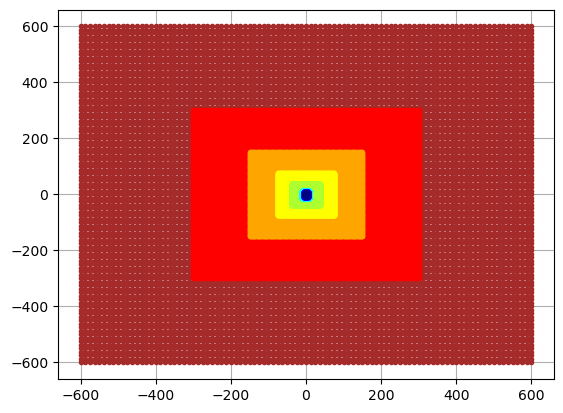

In [10]:

##################################################################
## 根据网格信息自动生成 AMSS-NCKU C++ 程序的输入文件
##################################################################

## 根据格点信息生成 cgh 的相关输入
numerical_grid.append_AMSSNCKU_cgh_input( input_language, initial_AMR_grid_data )  

## 画出初始的格点设置
numerical_grid.plot_initial_grid( input_language, initial_AMR_grid_data )


## 3 编译AMSS-NCKU代码 

### 根据AMSS_NCKU_Input.py中的设定来编译相关代码 

In [11]:

##################################################################
## 根据用户的要求编译 AMSS-NCKU 程序
##################################################################


##  根据算法和参数生成 AMSS-NCKU 的宏文件
main_program_function.generate_macrodef_file( input_language )

## 屏幕输出正在编译 AMSS-NCKU
print_information.print_compile_AMSS_NCKU( input_language )

AMSS_NCKU_source_path  = "AMSS_NCKU_source"
AMSS_NCKU_compile_path = os.path.join(File_directory, "AMSS_NCKU_compile")

###############################
## 如果 AMSS-NCKU 的源文件夹不存在，则创建它
###############################

# if not os.path.exists(destination_folder):
#     os.makedirs(destination_folder)

if not os.path.exists(AMSS_NCKU_source_path):
    os.makedirs(AMSS_NCKU_source_path)
    print_information.print_compile_AMSS_NCKU_debug( input_language )  ## 输出编译出错的信息
    
###############################
# 拷贝 AMSS-NCKU 的源文件，准备编译
###############################

shutil.copytree(AMSS_NCKU_source_path, AMSS_NCKU_compile_path)    

# 将整个src文件夹复制到dst位置
# shutil.copytree(src, dst)

###############################
# 将生成的宏文件拷贝进 AMSS-NCKU 的代码文件夹
###############################

macrodef_h_path  = os.path.join(File_directory, "macrodef.h") 
macrodef_fh_path = os.path.join(File_directory, "macrodef.fh") 

shutil.copy2(macrodef_h_path,  AMSS_NCKU_compile_path)
shutil.copy2(macrodef_fh_path, AMSS_NCKU_compile_path)

# 复制文件到目标位置
# shutil.copy2(source_file_path, target_location)
# shutil.copy2保留文件的元数据，如修改时间。如果你只想复制文件内容，不保留元数据，可以使用shutil.copy。

###############################
# 编译相关程序
###############################

import makefile_and_run

## 先切换到目标文件夹
os.chdir(AMSS_NCKU_compile_path)
 
## 编译 AMSS-NCKU 的主程序 ABE/ABEGPU
makefile_and_run.makefile_ABE( input_language )

## 如果初值方法选为 TwoPuncture，编译可执行文件 TwoPunctureABE 
## 如果初值方法选为其它方法，则跳过这一步

if (input_data.Initial_Data_Method == "Ansorg-TwoPuncture" ): 
    makefile_and_run.makefile_TwoPunctureABE( input_language )
else:
    print()
    
## 如果设置 puncture 的方式选为 Automatically-BBH，编译可执行文件 PNOrbit
## 如果设置 puncture 的方式选为 Manually，则跳过这一步

if (input_data.puncture_data_set == "Automatically-BBH" ): 
    makefile_and_run.makefile_PNOrbit( input_language )
elif (input_data.puncture_data_set == "Manually" ): 
    print()
    
###########################
## 改变当前工作目录到上一级目录
###############################

os.chdir('..')
os.chdir('..')

print()



 根据算法和参数生成 AMSS-NCKU 的宏文件 

 AMSS-NCKU 程序的宏文件 macrodef.h 已生成 
 AMSS-NCKU 程序的宏文件 macrodef.fh 已生成 

 准备根据要求编译并运行 AMSS-NCKU 程序 


 正在编译 AMSS-NCKU 程序 ABE/ABEGPU 

g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c ABE.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o ABE.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c Initial_Data_Solver/Ansorg.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o Initial_Data_Solver/Ansorg.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c cgh/Block.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o cgh/Block.o
gfortran  -c Special_Function/zbesh.for -o S

g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c Null_Evolve/NullShellPatch2_Evo.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o Null_Evolve/NullShellPatch2_Evo.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c Read_and_Write/writefile_f.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o Read_and_Write/writefile_f.o
gfortran  -O2 -x f95-cpp-input -c BSSN/enforce_algebra.f90 -o BSSN/enforce_algebra.o
gfortran  -O2 -x f95-cpp-input -c misc/fmisc.f90 -o misc/fmisc.o
gfortran  -O2 -x f95-cpp-input -c Initial_Data_Solver/initial_puncture.f90 -o Initial_Data_Solver/initial_puncture.o
gfortran  -O2 -x f95-cpp-input -c BSSN/prolongrestrict.f90 -o BSSN/prolongrestrict.o
gfortran  -O2 -x f95-cpp-input -c BSSN/prolongrestrict

g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/patch_interp.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o AHF_Direct/patch_interp.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/patch_system.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o AHF_Direct/patch_system.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/tgrid.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o AHF_Direct/tgrid.o
AHF_Direct/patch_system.C: In static member function ‘static int AHFinderDirect::patch_system::N_patches_of_type(patch_system_type)’:
AHF_Direct/patch_syste

g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/fd_grid.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o AHF_Direct/fd_grid.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/ghost_zone.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o AHF_Direct/ghost_zone.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/array.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/usr/lib/gcc/x86_64-linux-gnu/11/ -I/usr/include/c++/11/ -I/usr/lib/cuda/include -o AHF_Direct/array.o
g++ -O2 -Wno-deprecated -Dfortran3 -Dnewc  -c AHF_Direct/round.C -I/usr/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/include/ -I/usr/lib/x86_64-linux-gnu/openmpi/lib/ -I/

### 拷贝可执行文件到对应的文件夹

In [12]:

##################################################################
## 将 AMSS-NCKU 程序可执行文件 ABE 拷贝到程序运行的文件夹
##################################################################

if (input_data.GPU_Calculation == "no"):
    ABE_file = os.path.join(AMSS_NCKU_compile_path, "ABE")
elif (input_data.GPU_Calculation == "yes"):
    ABE_file = os.path.join(AMSS_NCKU_compile_path, "ABEGPU")

if not os.path.exists( ABE_file ):
    print_information.print_no_ABE_error( input_language )  ## 屏幕输出不存在 ABE/ABEGPU 的报错信息

## 复制可执行文件 ABE 到程序运行目录
shutil.copy2(ABE_file, output_directory)

##################################################################
## 如果初值方法选为 TwoPuncture，将 AMSS-NCKU 程序可执行文件 TwoPunctureABE 拷贝到程序运行的文件夹
##################################################################

TwoPuncture_file = os.path.join(AMSS_NCKU_compile_path, "TwoPunctureABE")

if ( input_data.Initial_Data_Method == "Ansorg-TwoPuncture" ):

    ## 如果找不到可执行文件 TwoPunctureABE，屏幕输出报错信息
    if not os.path.exists( TwoPuncture_file ):
        print_information.print_no_TwoPunture_error( input_language ) 

    ## 复制可执行文件 TwoPunctureABE 到程序运行目录
    shutil.copy2(TwoPuncture_file, output_directory)

##################################################################
## 如果设置 puncture 的方式选为 Automatically-BBH，将 AMSS-NCKU 程序可执行文件 PNOrbit 拷贝到程序运行的文件夹
##################################################################

PNOrbit_file = os.path.join(AMSS_NCKU_compile_path, "PNOrbit")

if ( input_data.puncture_data_set == "Automatically-BBH"  ):

    ## 如果找不到可执行文件 PNOrbit，屏幕输出报错信息
    if not os.path.exists( PNOrbit_file ):
        print_information.print_no_PNOrbit_error( input_language ) 

    ## 复制可执行文件 PNOrbit 到程序运行目录
    shutil.copy2(PNOrbit_file, output_directory)
    

### 运行TwoPuncture程序 

In [13]:

##################################################################
## 如果初值方法选为 TwoPuncture，生成 TwoPuncture 的输入文件
##################################################################

if ( input_data.Initial_Data_Method == "Ansorg-TwoPuncture" ):
    
    ## 屏幕输出生成 TwoPuncture 输入文件
    print_information.print_generate_TwoPunture_input( input_language )
    
    import generate_TwoPuncture_input
    
    ## 根据双星模型设定 TwoPuncture 需要的数据
    ## puncture_data = generate_TwoPuncture_input.generate_puncture_input_data( input_language )
    
    ## 生成 TwoPuncture 的输入文件
    generate_TwoPuncture_input.generate_AMSSNCKU_TwoPuncture_input( input_language, puncture_data )
    print_information.print_finish_TwoPunture_input( input_language )   ## 屏幕输出 TwoPuncture 的输入文件已完成
    
    ## 生成的 AMSS-NCKU 输入文件名
    AMSS_NCKU_TwoPuncture_inputfile      = 'AMSS-NCKU-TwoPuncture.input'
    AMSS_NCKU_TwoPuncture_inputfile_path = os.path.join( File_directory, AMSS_NCKU_TwoPuncture_inputfile )
 
    ## 复制并重命名文件
    shutil.copy2( AMSS_NCKU_TwoPuncture_inputfile_path, os.path.join(output_directory, 'TwoPunctureinput.par') )
    
    ###########################
    ## 运行 TwoPuncture 来生成初值文件
    ###########################
    
    print()
    ## print( " 准备启动 AMSS-NCKU TwoPuncture 程序 ，按回车继续！！！ " )
    ## inputvalue = input()                    
    ## print()
    
    ## 先切换到目标文件夹
    os.chdir(output_directory)

    ## 运行 TwoPuncture 程序
    makefile_and_run.run_TwoPunctureABE( input_language )
    
    ###########################
    ## 改变当前工作目录到上两级目录
    ###########################
    
    os.chdir('..')
    os.chdir('..')


### 更新AMSS-NCKU中动力学演化所需要的 puncture 数据，使计算更加准确

In [14]:
    
##################################################################    
## 根据 TwoPuncture 的运行结果来更新 puncture 数据
## 或用其他方式更新 puncture 数据
##################################################################

import renew_puncture_parameter
    
renew_puncture_parameter.append_AMSSNCKU_BSSN_input( puncture_data, File_directory, output_directory )


## 生成的 AMSS-NCKU 输入文件名
AMSS_NCKU_inputfile      = 'AMSS-NCKU.input'
AMSS_NCKU_inputfile_path = os.path.join(File_directory, AMSS_NCKU_inputfile)
 
## 复制并重命名文件
shutil.copy2( AMSS_NCKU_inputfile_path, os.path.join(output_directory, 'input.par') )

## 屏幕输出成功拷贝参数文件
print_information.copy_input_parfile( input_language )



 成功将生成的 AMSS-NCKU 程序输入文件复制到运行目录 



## 运行AMSS-NCKU可执行程序 

In [15]:

##################################################################
## 运行演化程序
##################################################################

## 准备启动 AMSS-NCKU 的可执行程序 ABE/ABEGPU
print_information.print_begin_ABE( input_language )

## 先切换到目标文件夹
os.chdir( output_directory )

## 执行 ABE/ABEGPU
makefile_and_run.run_ABE( input_language )

## 改变当前工作目录到上两级目录
os.chdir('..')
os.chdir('..')



 准备启动 AMSS-NCKU 的可执行程序 ABE/ABEGPU 


 正在运行 AMSS-NCKU 主程序 ABE/ABEGPU 


 /////////////////////////////////////////////////////////////// 
 AMSS-NCKU Begin !!! 
 /////////////////////////////////////////////////////////////// 

                                 new run
   simulation with cpu numbers = 6
               simulation time = (0, 20)
 simulation steps for this run = 10000000
                Courant number = 0.5
            Initial Data Type: Analytical NBH (Cao's Formula)
             Symmetry setting: Equatorial
 Courant = 0.5
 artificial dissipation for shell patches = 0.15
 artificial dissipation for fixed levels = 0.15
 artificial dissipation for moving levels = 0.15
 Dumpt Time = 100
 Check Time = 100
 Analysis Time = 0.1
 Analysis level = 0
 checkfile = bssn.chk
 sixth order finite difference is used
///////////////////////////////////////////////////////////////
-----------------------------------------------------------------------
 spherical integration for wave form e


 Timestep # 12: integrating to time: 9.375    Computer used 47.8157 seconds! 
 Memory usage: current 5976/995.9/5976MB, peak 6361/1060/6361MB

 puncture position: no. 0 = (-1.4502e-18 -2.86405 1.01186e-16)
 puncture position: no. 1 = (-7.51003e-16 2.86382 2.35498e-17)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 13: integrating to time: 10.1562    Computer used 47.0889 seconds! 
 Memory usage: current 6408/1068/6408MB, peak 6408/1068/6408MB

 puncture position: no. 0 = (2.4361e-16 -2.83304 7.40208e-17)
 puncture position: no. 1 = (-3.20233e-16 2.8322 7.74422e-17)

 If you think the physical evolution time is enough for this simulation, please input 'stop' in the terminal to stop the MPI processes in the next evolution step ! 

 Timestep # 14: integrating to time: 10.9375    Computer used 47.1522 seconds! 
 Memory usage: current 6408/1068/6408MB, peak 64

## 对AMSS-NCKU的运行结果进行画图

### 拷贝AMSS-NCKU的文本文件输出，

In [16]:

##################################################################
## 将一些基本输入拷贝出来，方便进行 debug
##################################################################

## 用于输出计算所用参数的文件地址
AMSS_NCKU_error_file_path = os.path.join(binary_results_directory, "setting.par")
## 复制并重命名文件
shutil.copy( AMSS_NCKU_error_file_path, os.path.join(output_directory, "AMSSNCKU_setting_parameter") )

## 用于报错的文件地址
AMSS_NCKU_error_file_path = os.path.join(binary_results_directory, "Error.log")
## 复制并重命名文件
shutil.copy( AMSS_NCKU_error_file_path, os.path.join(output_directory, "Error.log") )

## 程序基本输出
AMSS_NCKU_BH_data         = os.path.join(binary_results_directory, "bssn_BH.dat"        )
AMSS_NCKU_ADM_data        = os.path.join(binary_results_directory, "bssn_ADMQs.dat"     )
AMSS_NCKU_psi4_data       = os.path.join(binary_results_directory, "bssn_psi4.dat"      )
AMSS_NCKU_constraint_data = os.path.join(binary_results_directory, "bssn_constraint.dat")
## 复制并重命名文件
shutil.copy( AMSS_NCKU_BH_data,         os.path.join(output_directory, "bssn_BH.dat"        ) )
shutil.copy( AMSS_NCKU_ADM_data,        os.path.join(output_directory, "bssn_ADMQs.dat"     ) )
shutil.copy( AMSS_NCKU_psi4_data,       os.path.join(output_directory, "bssn_psi4.dat"      ) )
shutil.copy( AMSS_NCKU_constraint_data, os.path.join(output_directory, "bssn_constraint.dat") )

## 程序其它输出
if (input_data.Equation_Class == "BSSN-EM"):
    AMSS_NCKU_phi1_data = os.path.join(binary_results_directory, "bssn_phi1.dat" )
    AMSS_NCKU_phi2_data = os.path.join(binary_results_directory, "bssn_phi2.dat" )
    shutil.copy( AMSS_NCKU_phi1_data, os.path.join(output_directory, "bssn_phi1.dat" ) )
    shutil.copy( AMSS_NCKU_phi2_data, os.path.join(output_directory, "bssn_phi2.dat" ) )
elif (input_data.Equation_Class == "BSSN-EScalar"):
    AMSS_NCKU_maxs_data = os.path.join(binary_results_directory, "bssn_maxs.dat" )
    shutil.copy( AMSS_NCKU_maxs_data, os.path.join(output_directory, "bssn_maxs.dat" ) )
    

### 对AMSS-NCKU的运行结果进行画图

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



 画图结束，下面来制作动画 


 准备对 AMSS-NCKU 程序运行结果进行画图 


 正在对黑洞轨迹进行画图 

 对应数据文件为  BBH_test3/AMSS_NCKU_output/binary_output/bssn_BH.dat


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



 对黑洞轨迹画图完成 


 正在对黑洞轨迹进行画 3 维图 

 对应数据文件为  BBH_test3/AMSS_NCKU_output/binary_output/bssn_BH.dat

 对黑洞轨迹 3 维画图完成 


 正在对黑洞间距进行画图 

 对应数据文件为  BBH_test3/AMSS_NCKU_output/binary_output/bssn_BH.dat

 正在对黑洞间距画图完成 


 对 Weyl 共形变量 Psi4 进行画图 

 对应数据文件为  BBH_test3/AMSS_NCKU_output/binary_output/bssn_psi4.dat

 对第  0  个探测器半径数据进行画图 
 第  0  个探测器半径数据画图完成 


 对引力波强度 h 进行画图 

 对应数据文件为  BBH_test3/AMSS_NCKU_output/binary_output/bssn_psi4.dat


 对第  0  个探测器半径数据进行画图 
 第  0  个探测器半径数据画图完成 

 对第  1  个探测器半径数据进行画图 
 第  1  个探测器半径数据画图完成 


 对第  1  个探测器半径数据进行画图 
 第  1  个探测器半径数据画图完成 

 对第  2  个探测器半径数据进行画图 
 第  2  个探测器半径数据画图完成 


 对第  2  个探测器半径数据进行画图 
 第  2  个探测器半径数据画图完成 

 对第  3  个探测器半径数据进行画图 
 第  3  个探测器半径数据画图完成 


 对第  3  个探测器半径数据进行画图 
 第  3  个探测器半径数据画图完成 

 对第  4  个探测器半径数据进行画图 
 第  4  个探测器半径数据画图完成 


 对第  4  个探测器半径数据进行画图 
 第  4  个探测器半径数据画图完成 

 对第  5  个探测器半径数据进行画图 
 第  5  个探测器半径数据画图完成 


 对第  5  个探测器半径数据进行画图 
 第  5  个探测器半径数据画图完成 

 对第  6  个探测器半径数据进行画图 
 第  6  个探测器半径数据画图完成 


 对第  6  个探测器半径数据进行画图 
 第  6  个探测器半径

/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_xiaoqu.py:847: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure( figsize=(8,8) )                                   ## 这里 figsize 可以设定图形的大小


...

 二进制文件 =  Lev07-01_gyz0_00000.bin  画图已完成 


 正在读取二进制文件 =  Lev07-01_gzz0_00000.bin
 读取的数组大小 =  (115351,)
 读取的数组长度 =  115351
 原始设定的数组长度 =  61 * 61 * 31  =  115351
 格点坐标最小值 =  [-2.9296875, 0.09765625, 0.0]
 格点坐标最大值 =  [2.9296875, 5.95703125, 2.9296875]
 格点数目       =  [61, 61, 31]

 数据读取完成，接下来开始画图 



/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_binary_data.py:223: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  X_new, Y_new, data_xy_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线
/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_binary_data.py:327: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  X_new, Z_new, data_xz_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线
/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_binary_data.py:431: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  Y_new, Z_new, data_yz_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线


 二进制文件 =  Lev07-01_gzz0_00000.bin  画图已完成 


 正在读取二进制文件 =  Lev07-01_phi0_00000.bin
 读取的数组大小 =  (115351,)
 读取的数组长度 =  115351
 原始设定的数组长度 =  61 * 61 * 31  =  115351
 格点坐标最小值 =  [-2.9296875, 0.09765625, 0.0]
 格点坐标最大值 =  [2.9296875, 5.95703125, 2.9296875]
 格点数目       =  [61, 61, 31]

 数据读取完成，接下来开始画图 

 二进制文件 =  Lev07-01_phi0_00000.bin  画图已完成 


 正在读取二进制文件 =  Lev07-01_trK0_00000.bin
 读取的数组大小 =  (115351,)
 读取的数组长度 =  115351
 原始设定的数组长度 =  61 * 61 * 31  =  115351
 格点坐标最小值 =  [-2.9296875, 0.09765625, 0.0]
 格点坐标最大值 =  [2.9296875, 5.95703125, 2.9296875]
 格点数目       =  [61, 61, 31]

 数据读取完成，接下来开始画图 



/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_binary_data.py:223: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  X_new, Y_new, data_xy_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线
/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_binary_data.py:327: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  X_new, Z_new, data_xz_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线
/home/zrway/AMSS-NCKU-Python-Data/version 10c/plot_binary_data.py:431: UserWarning: No contour levels were found within the data range.
  contour  = ax.contour(  Y_new, Z_new, data_yz_fit, 8, colors='k', linewidths=0.5 )     # 添加等高线


 二进制文件 =  Lev07-01_trK0_00000.bin  画图已完成 


 二进制数据画图已完成 


 程序顺利结束，谢谢您的使用 



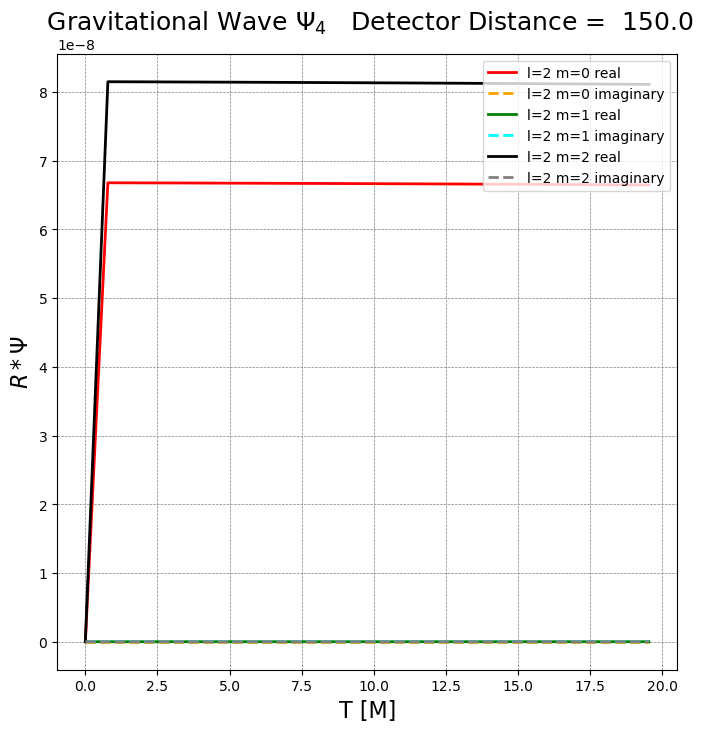

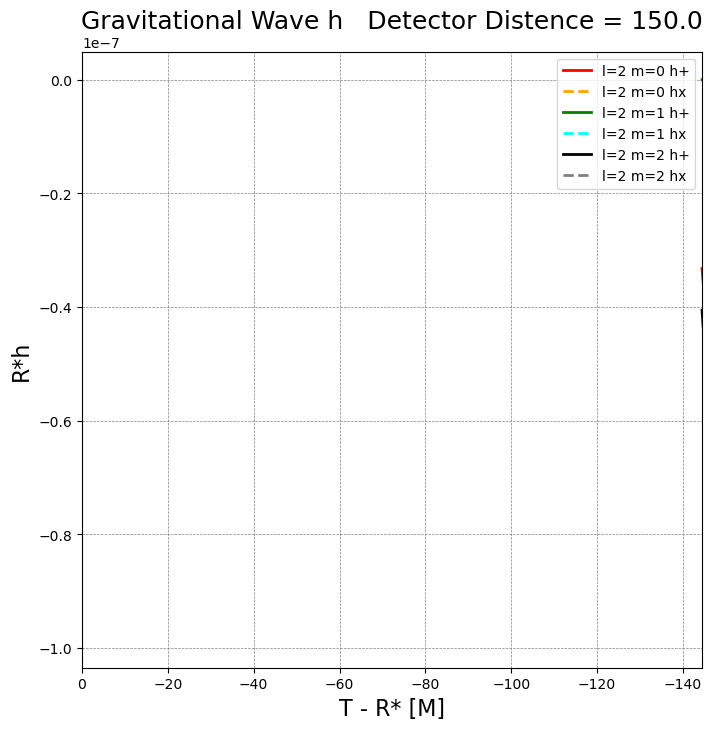

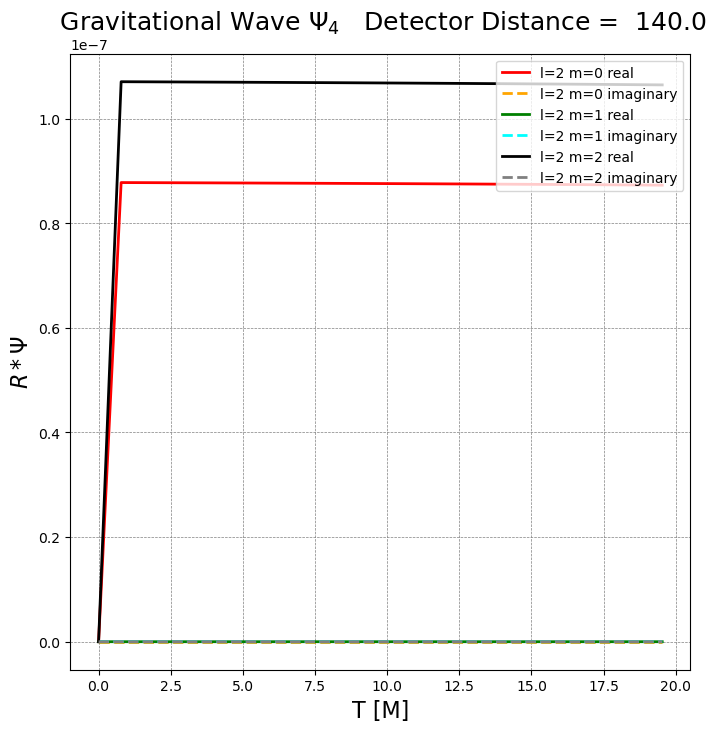

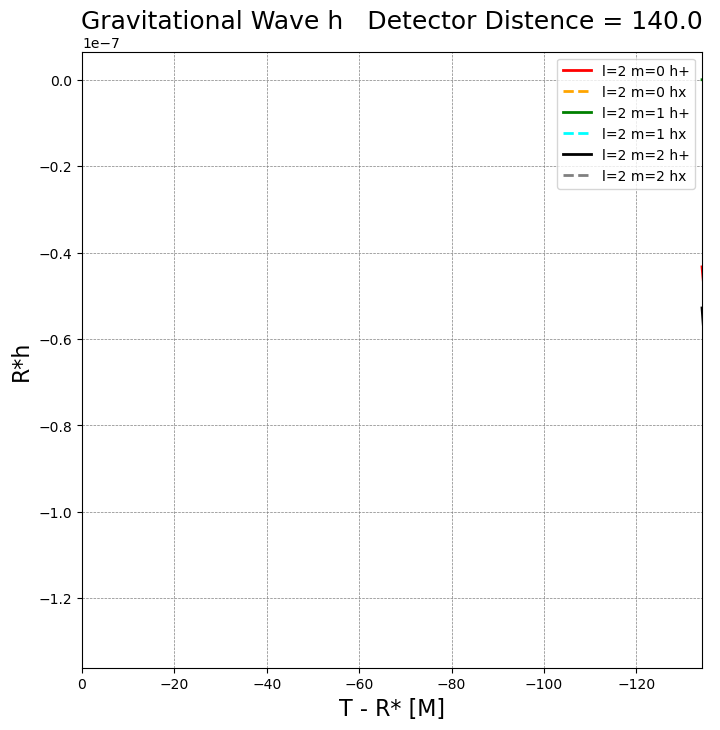

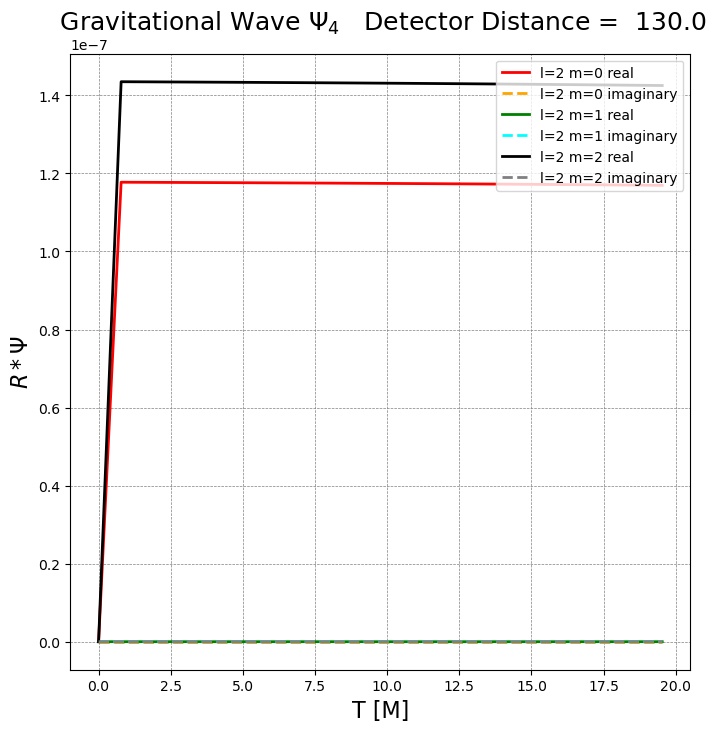

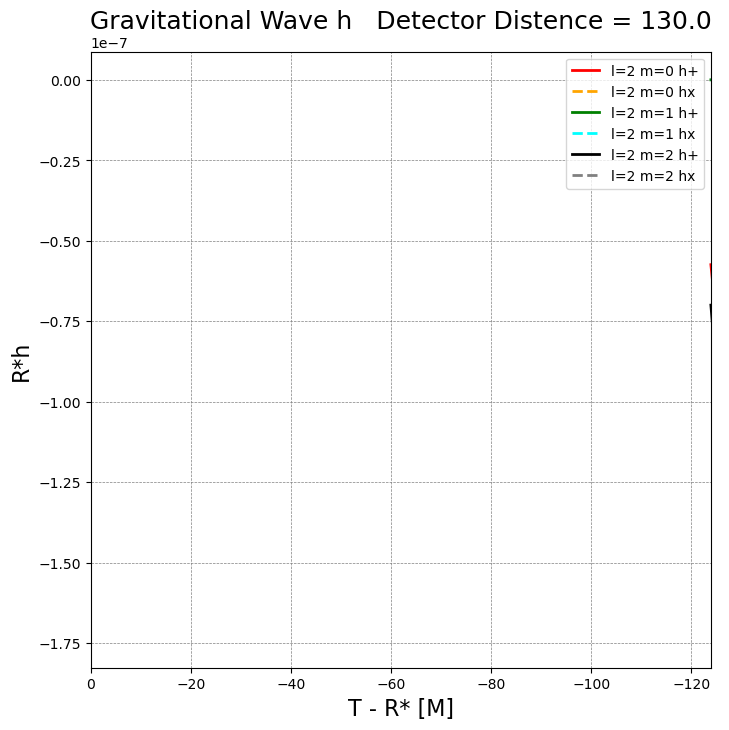

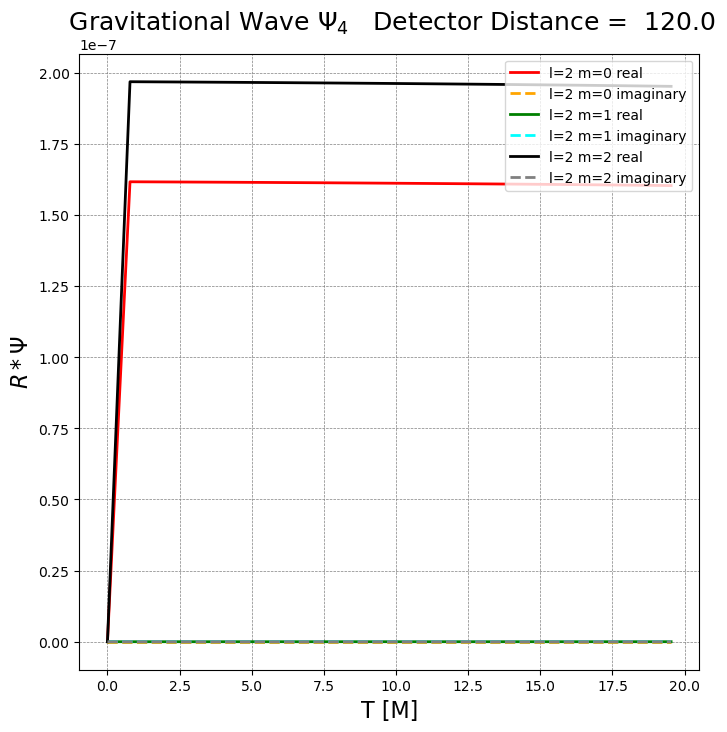

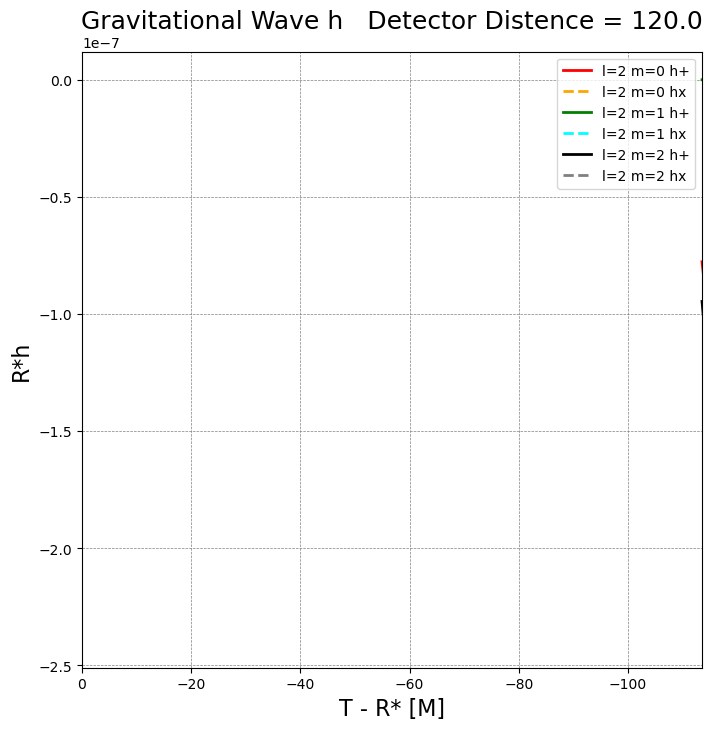

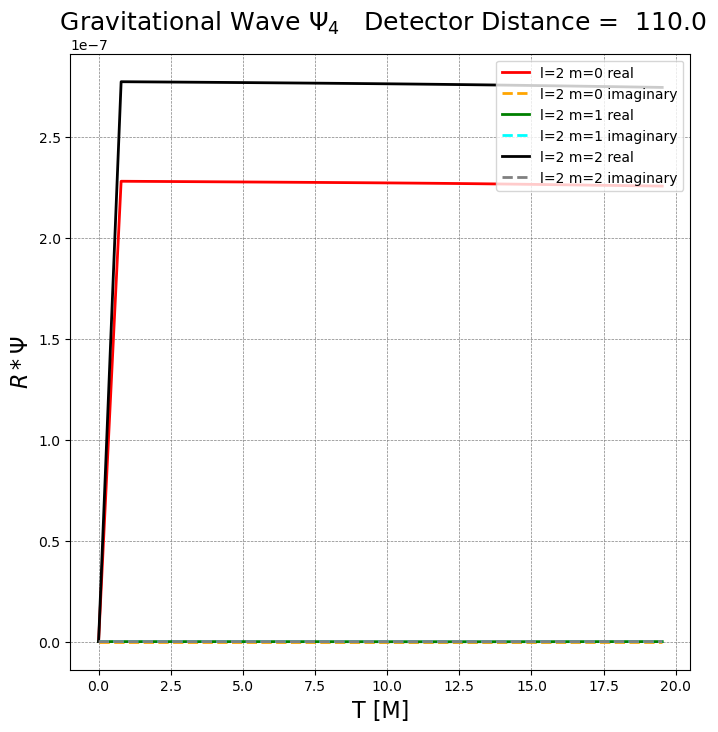

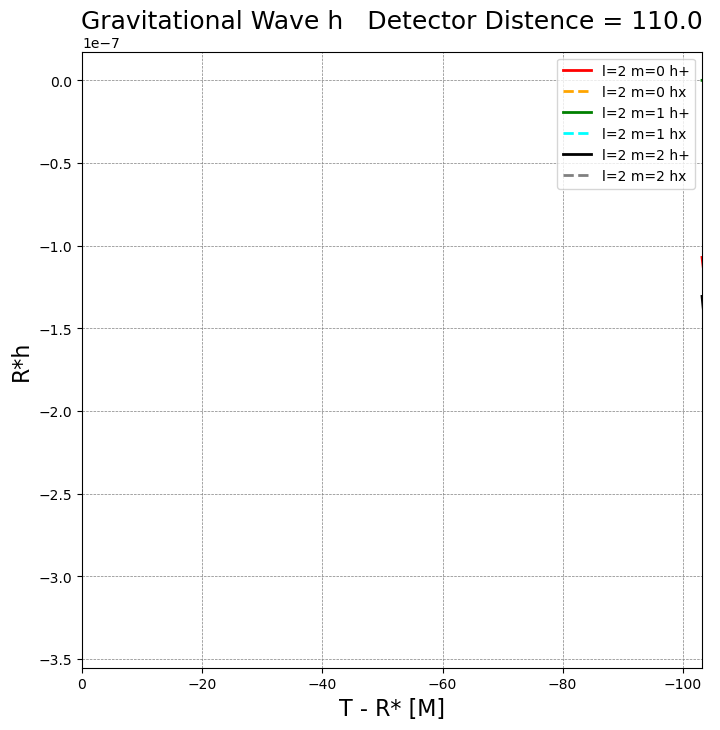

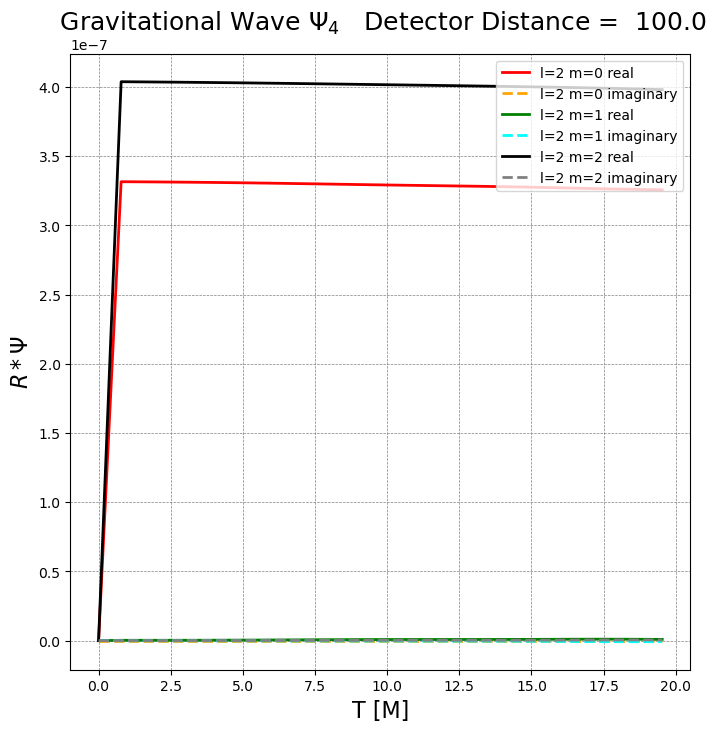

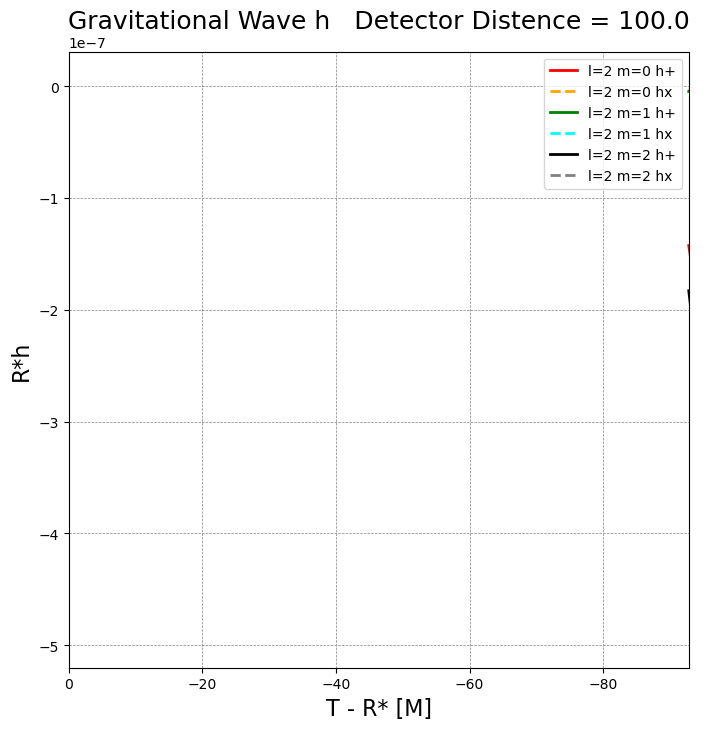

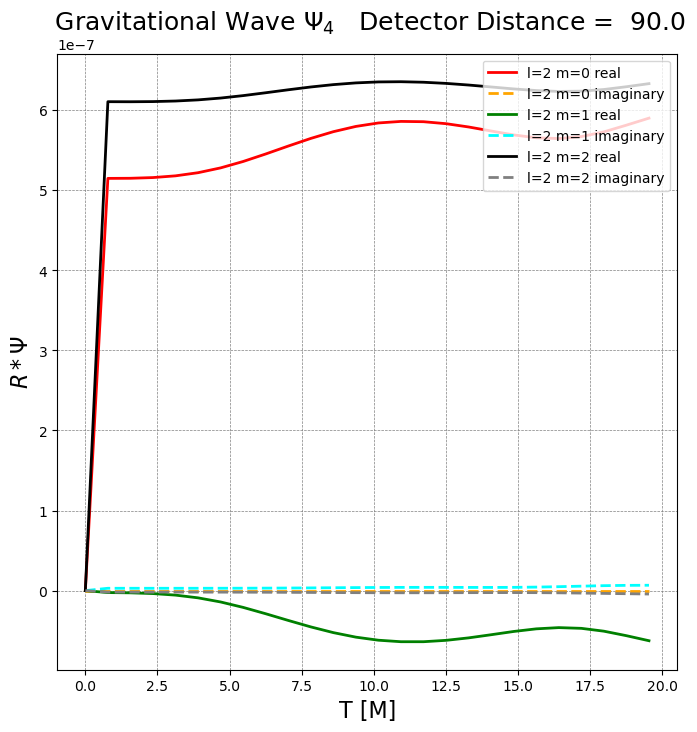

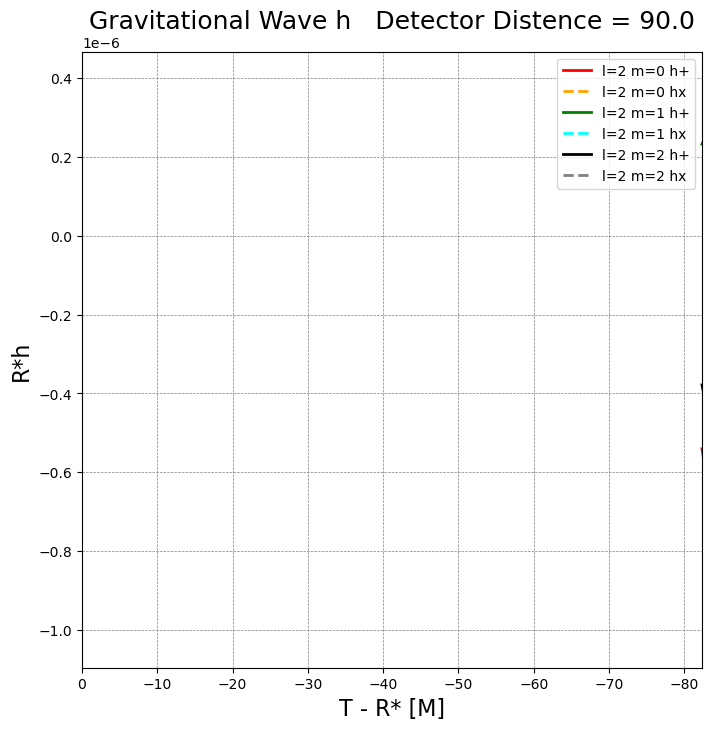

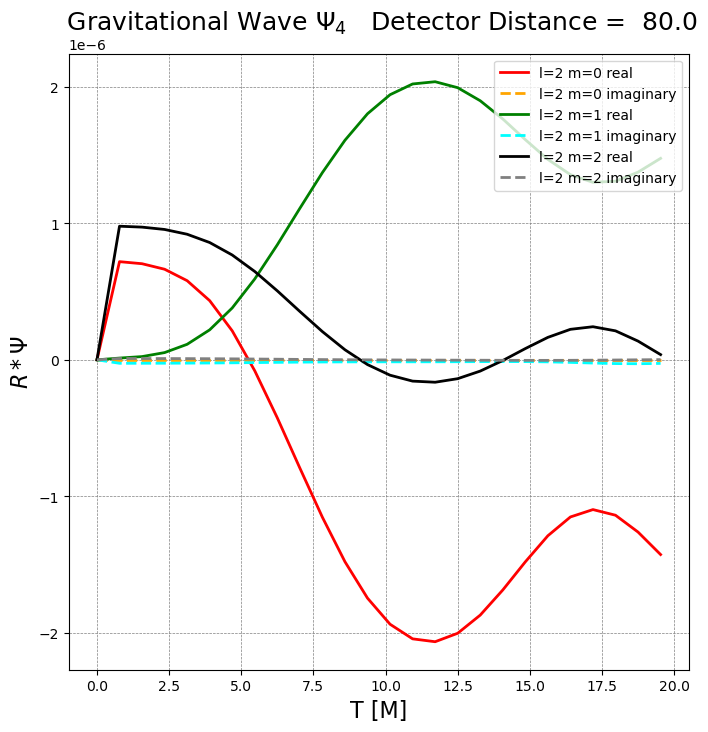

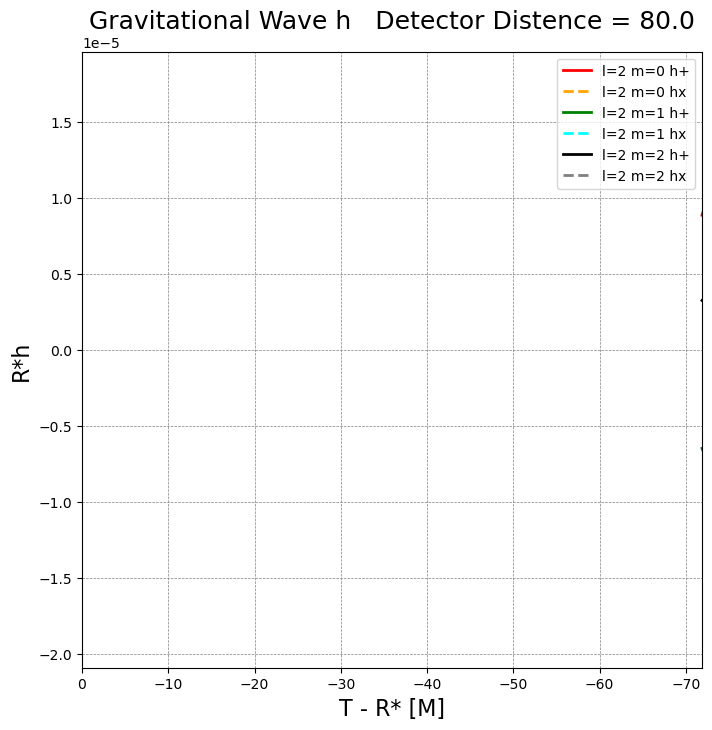

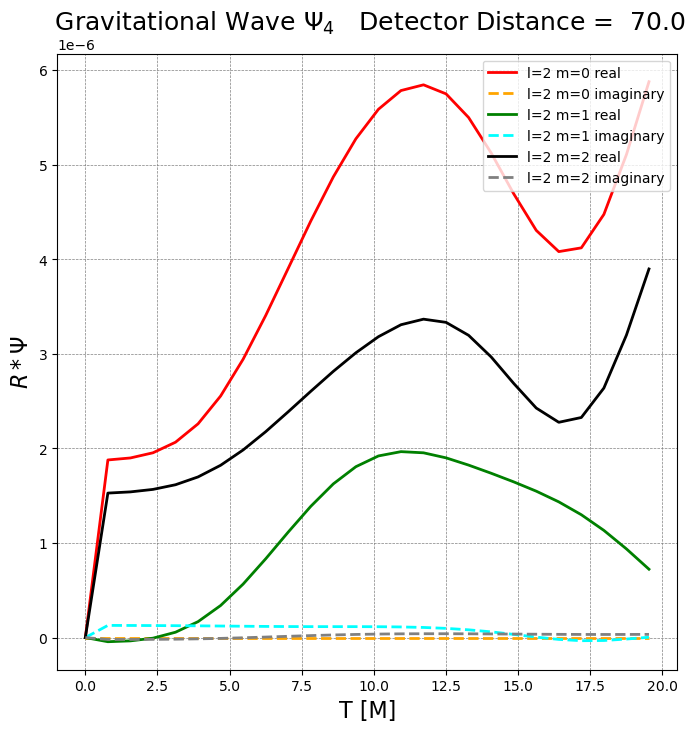

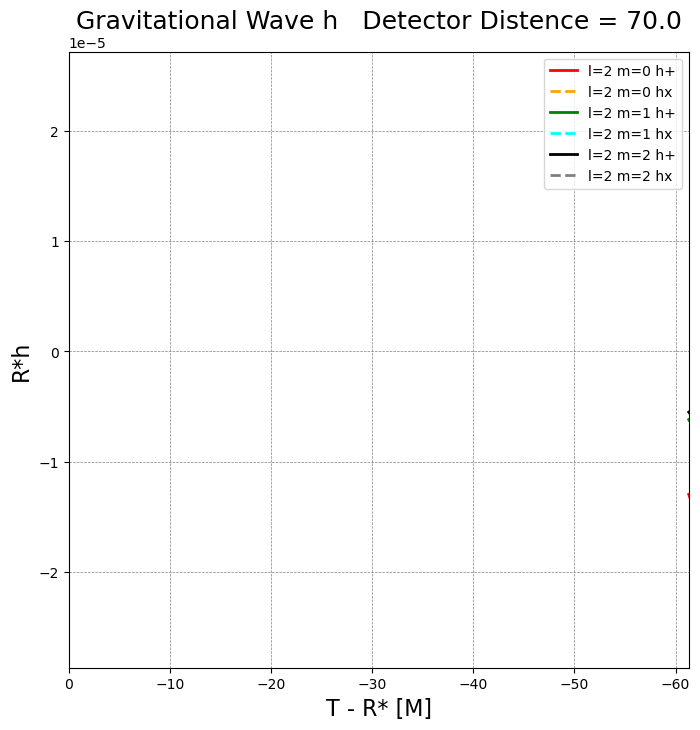

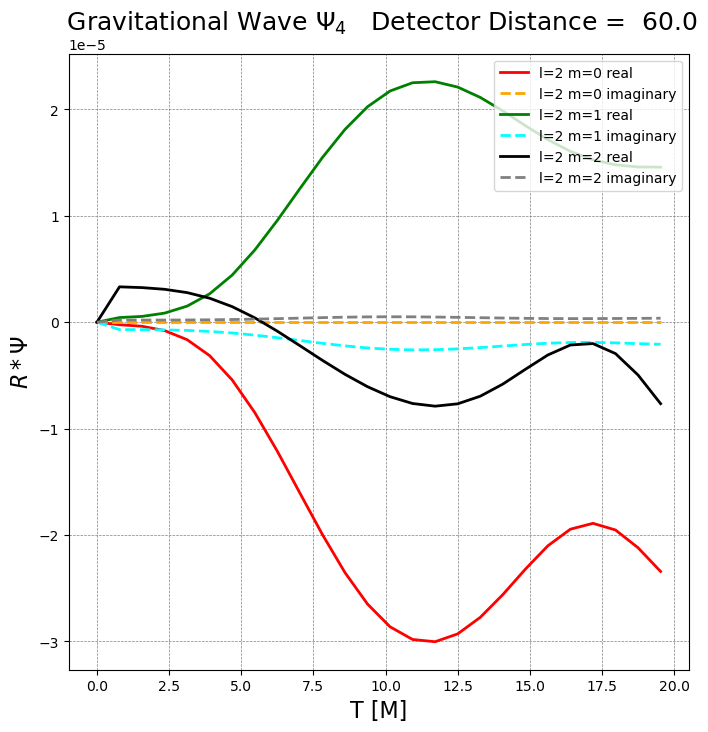

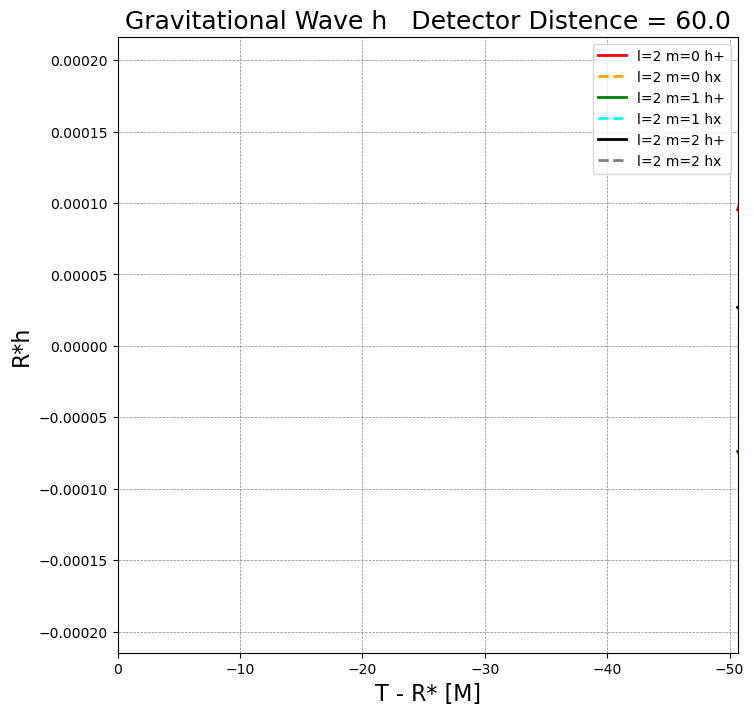

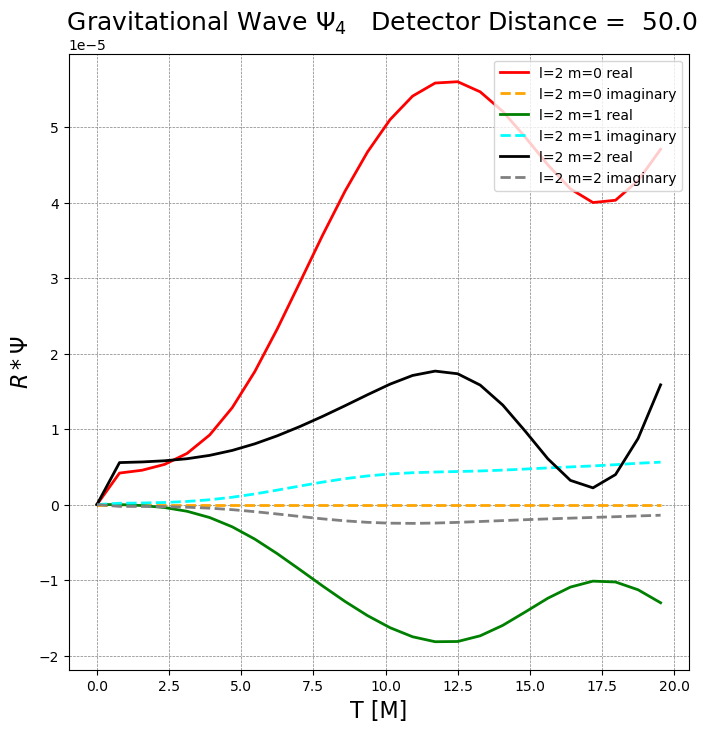

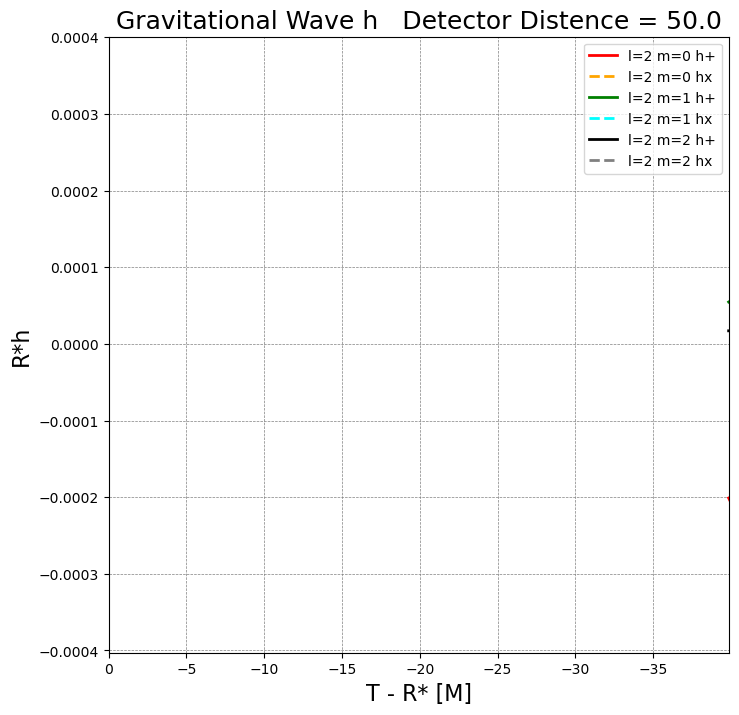

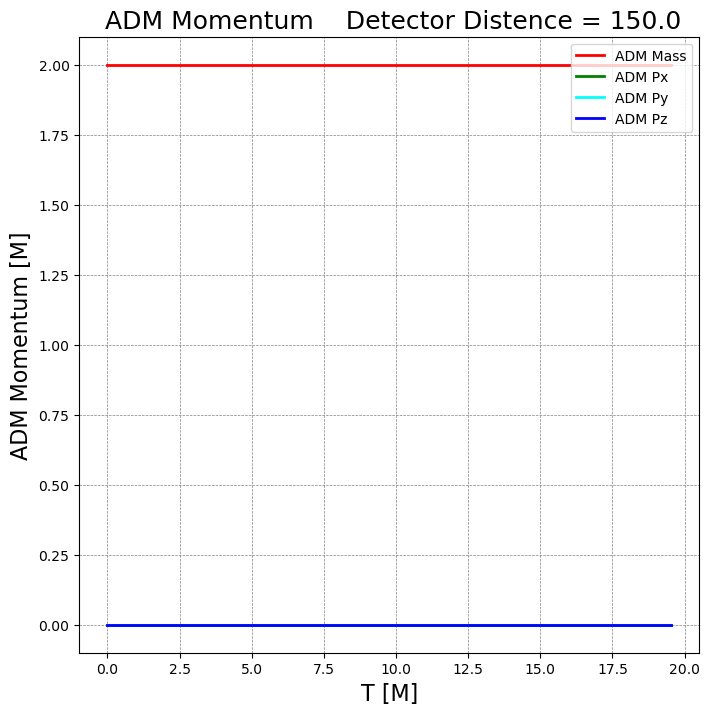

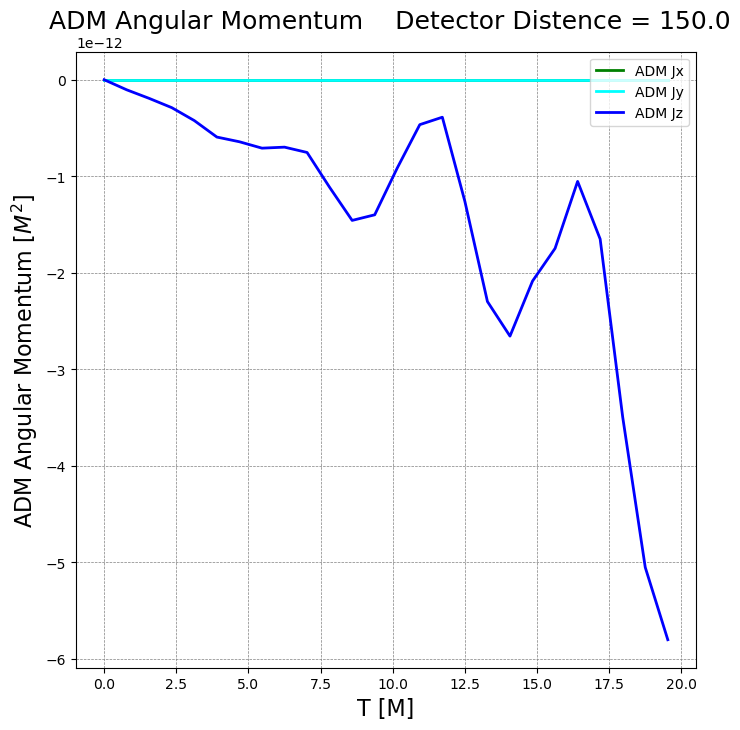

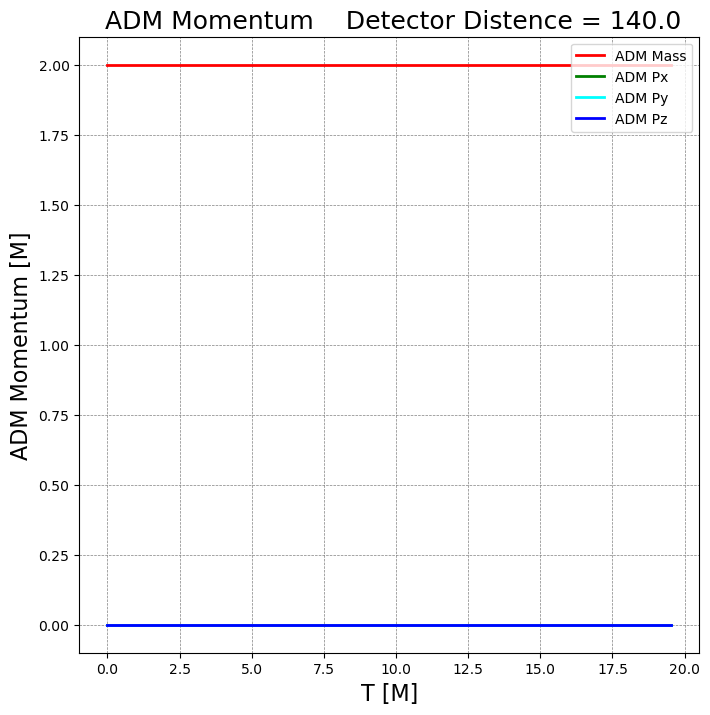

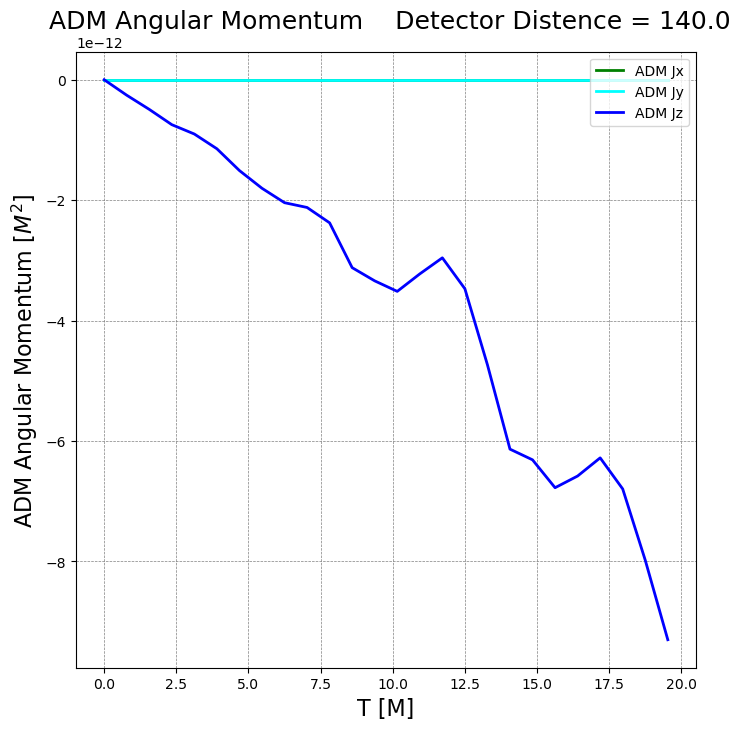

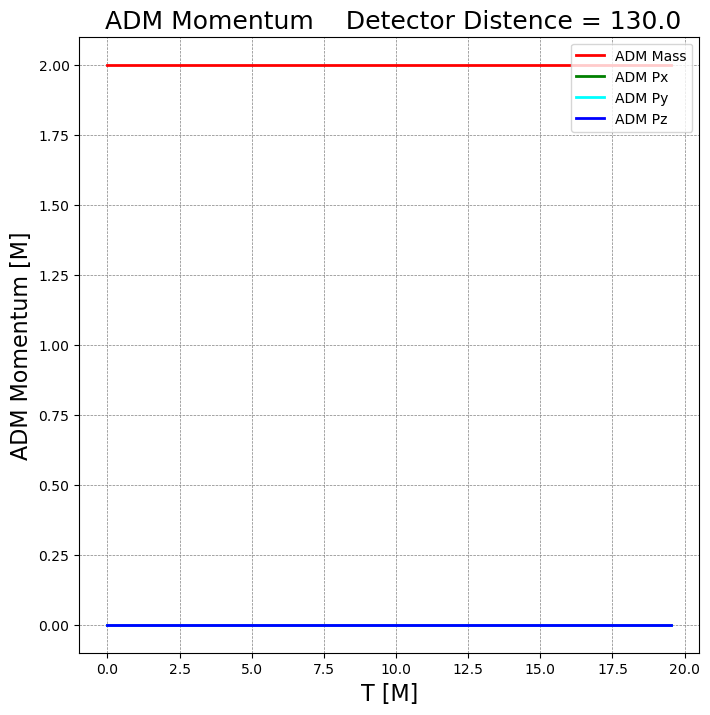

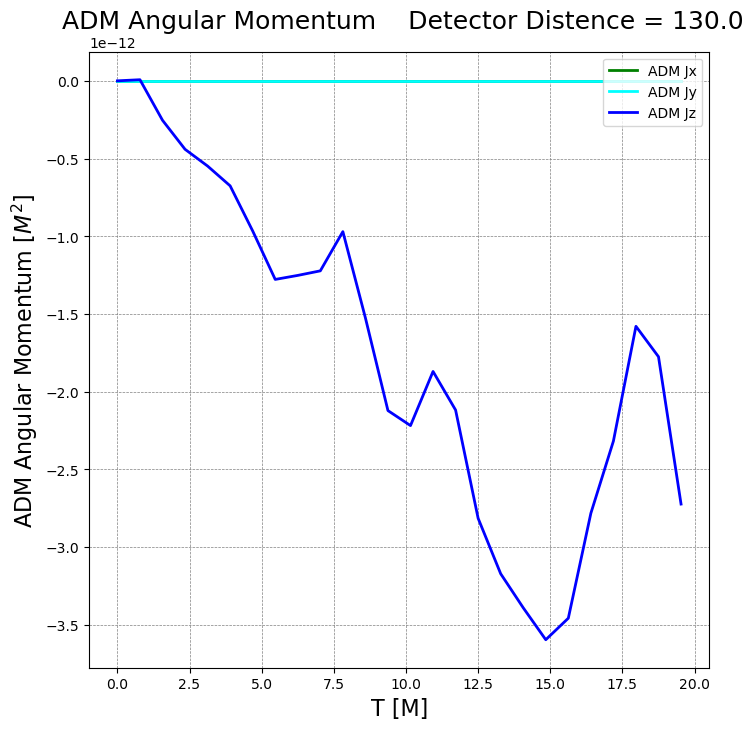

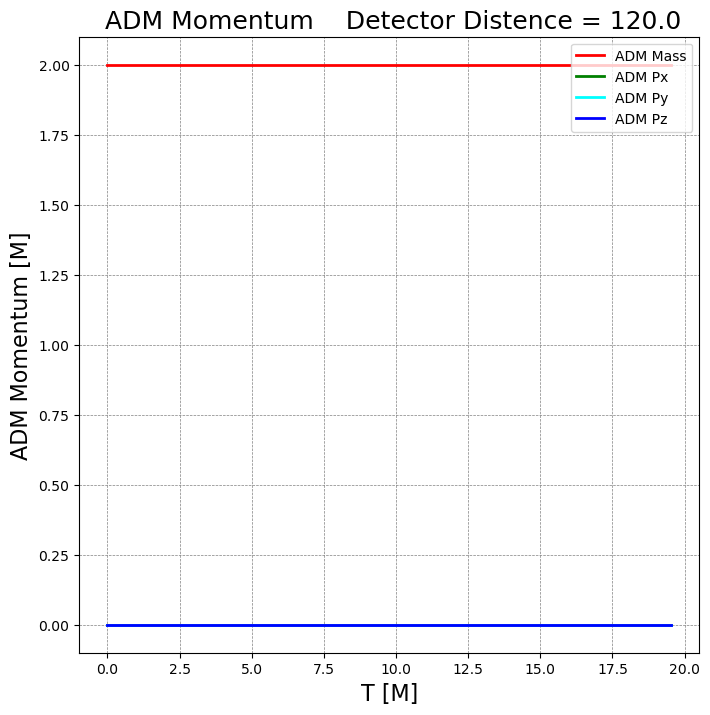

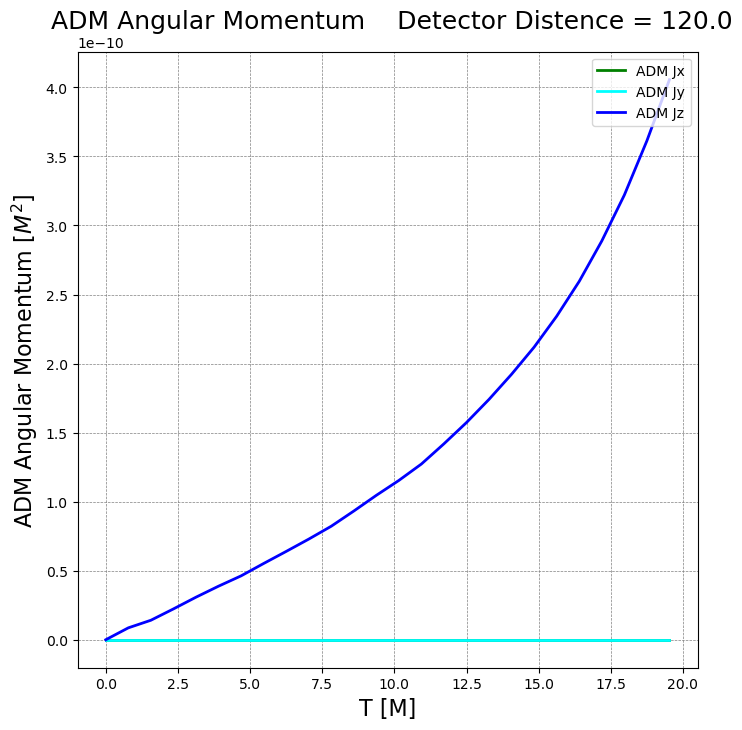

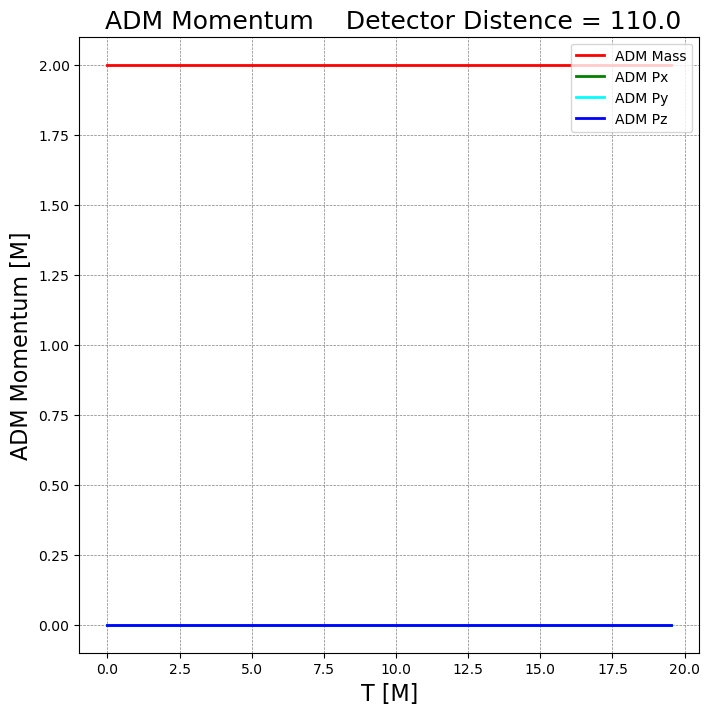

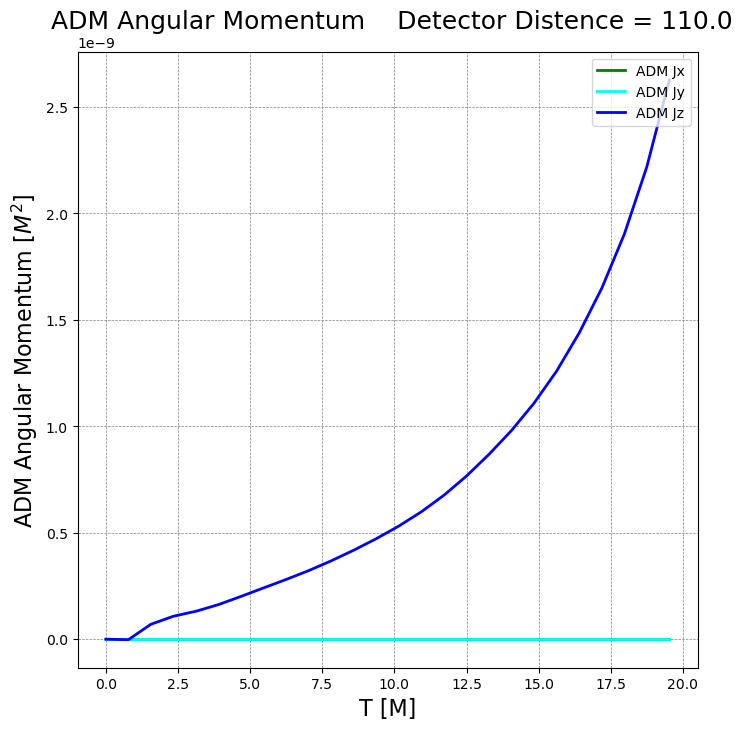

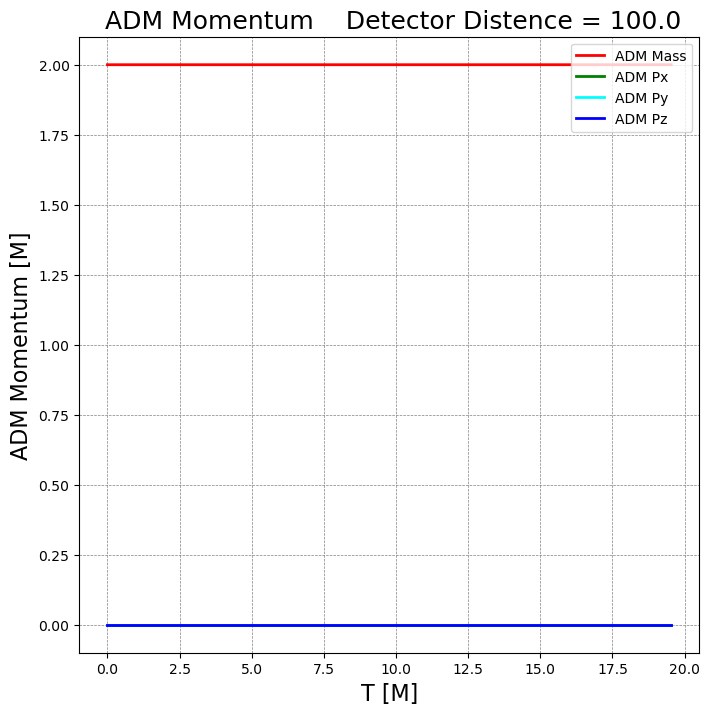

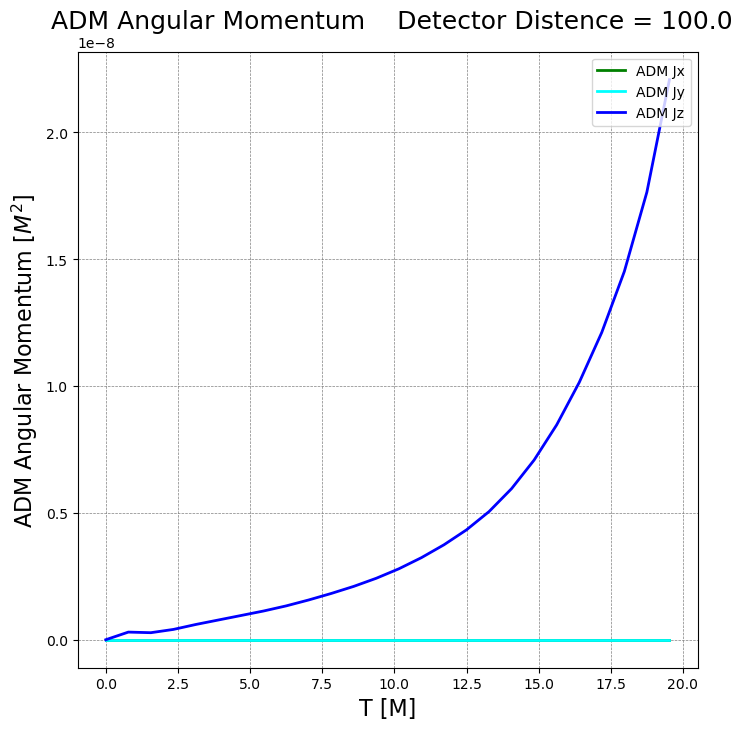

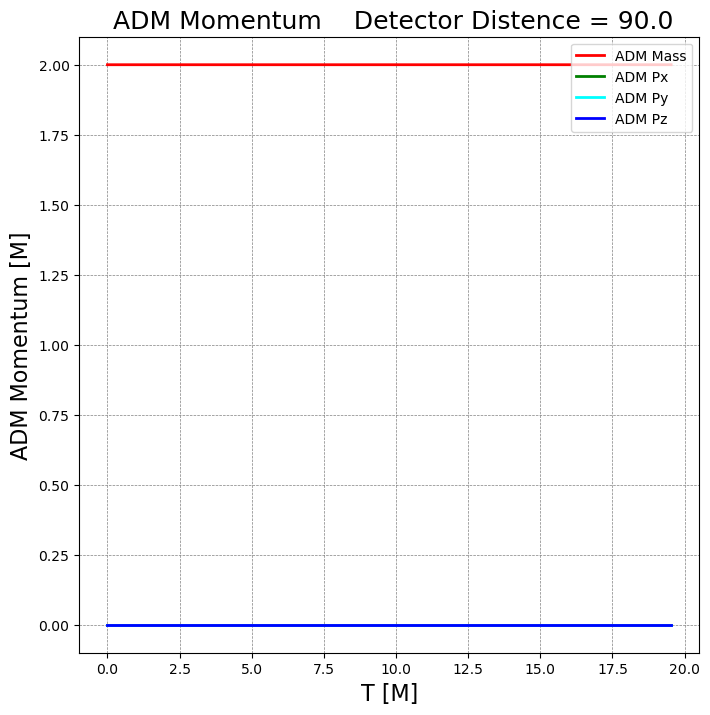

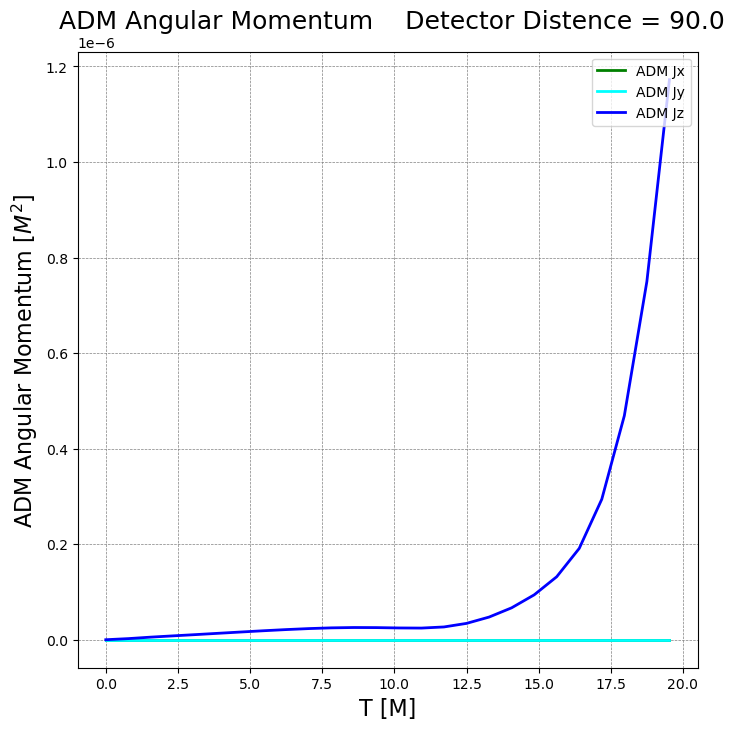

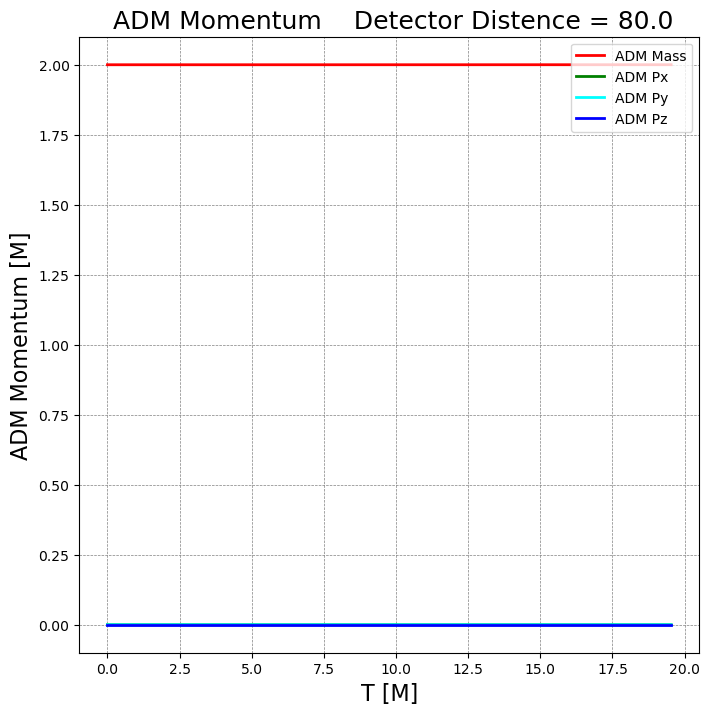

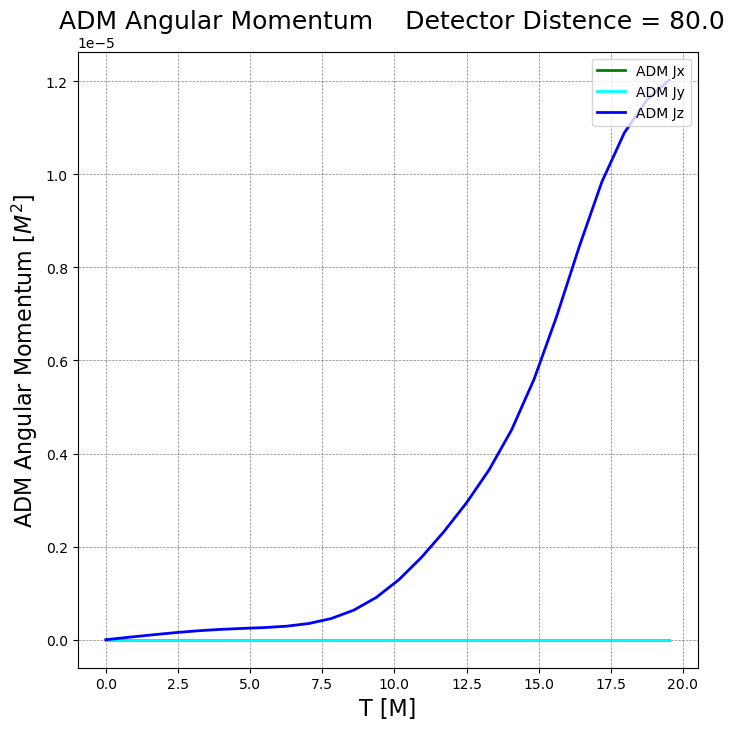

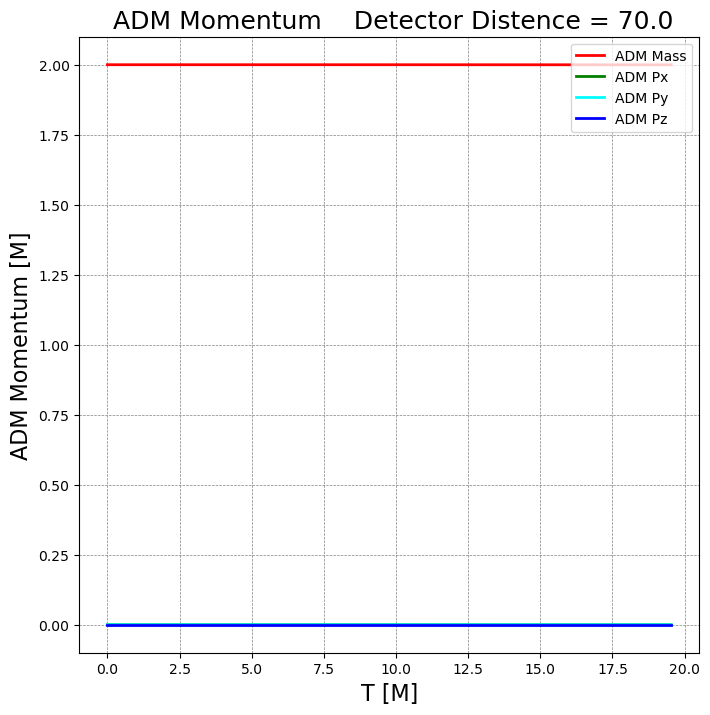

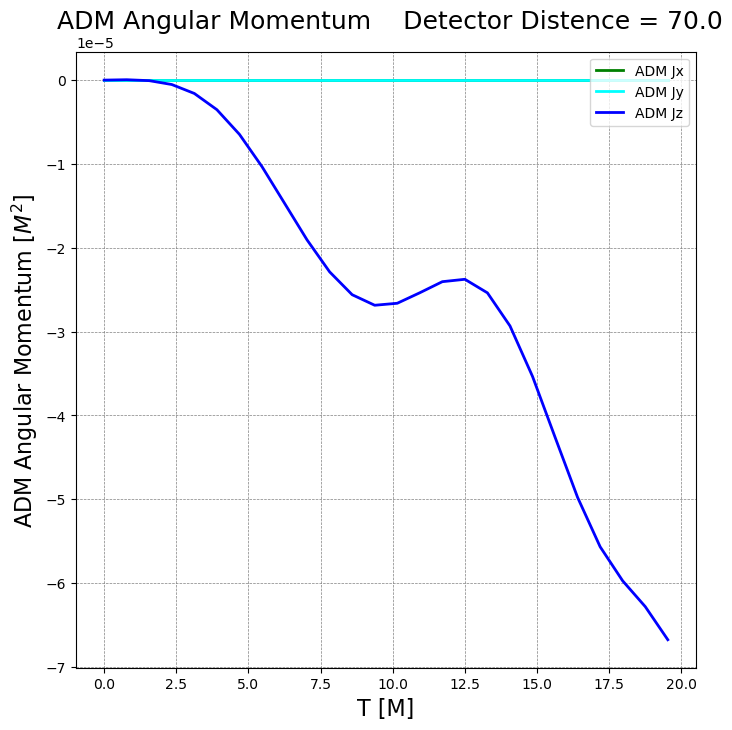

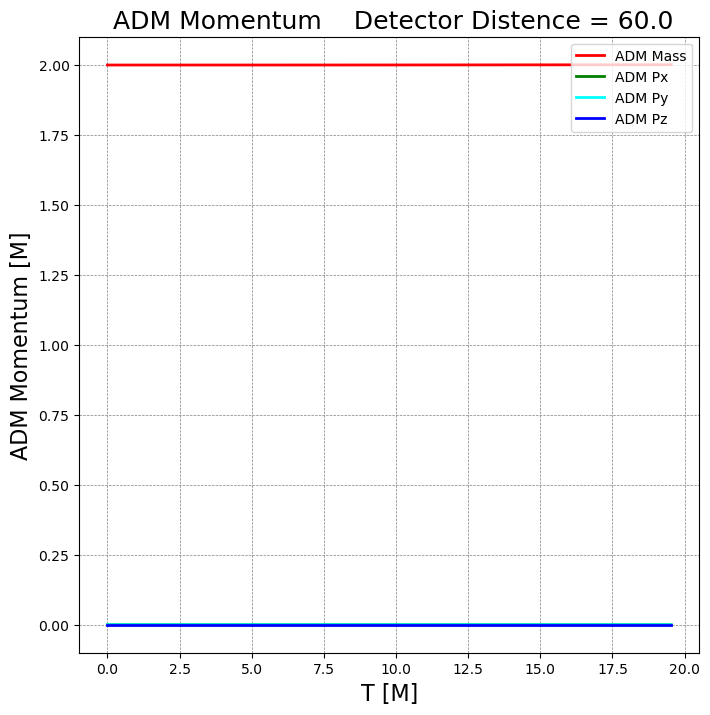

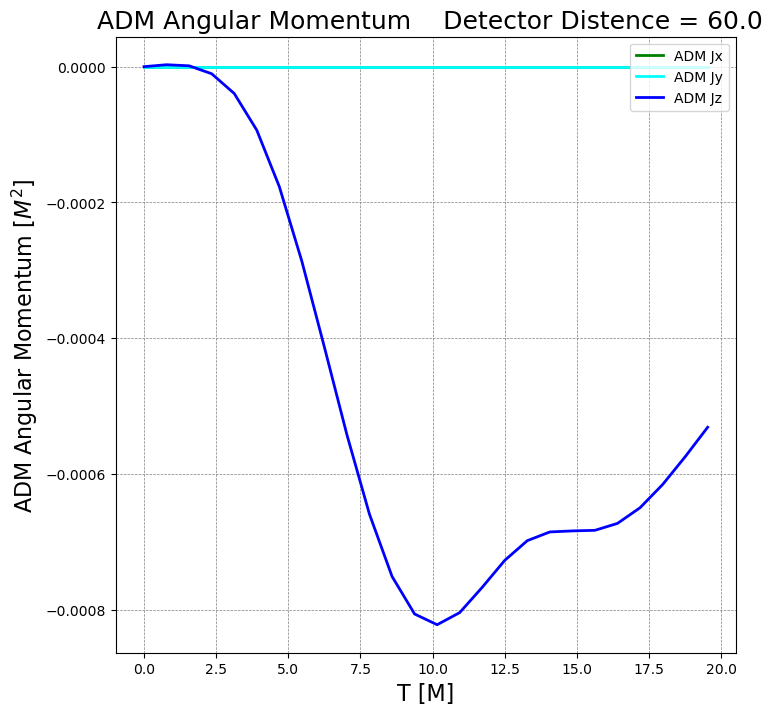

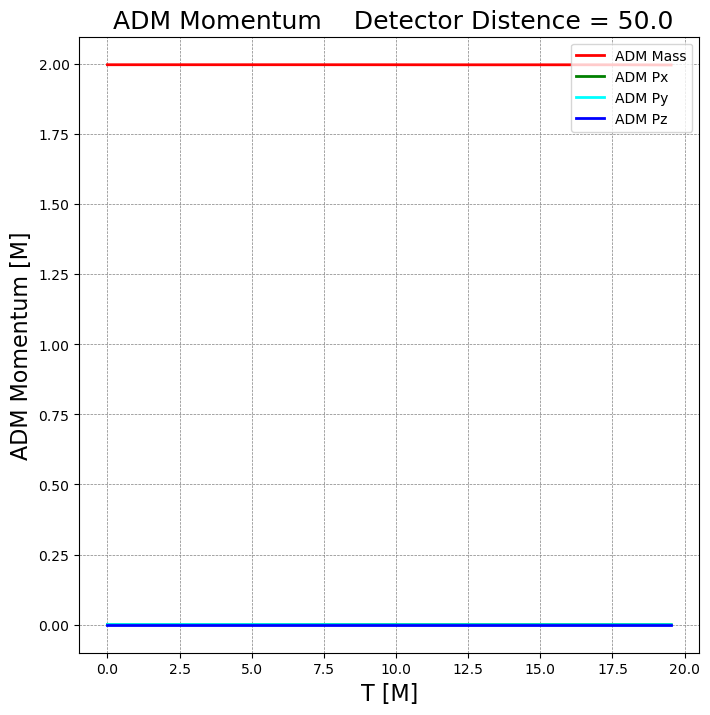

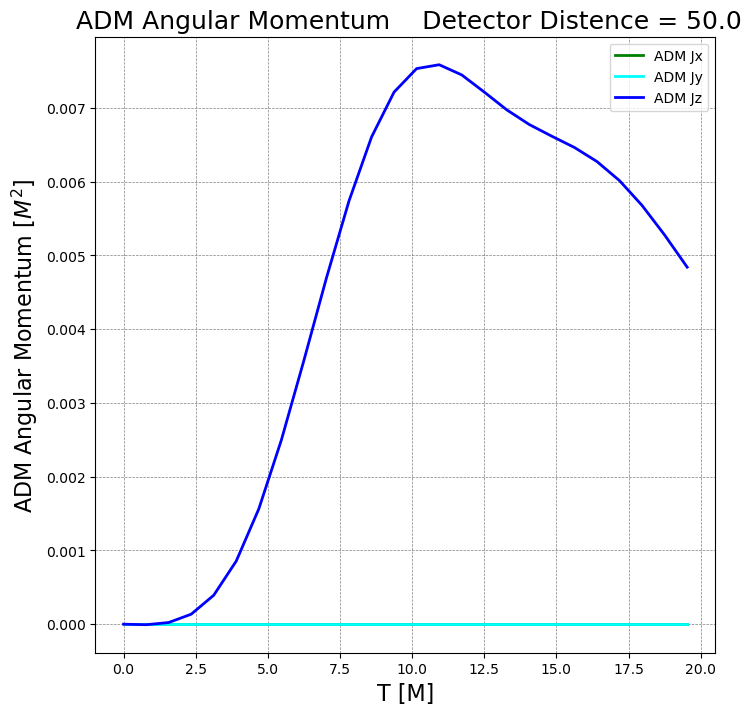

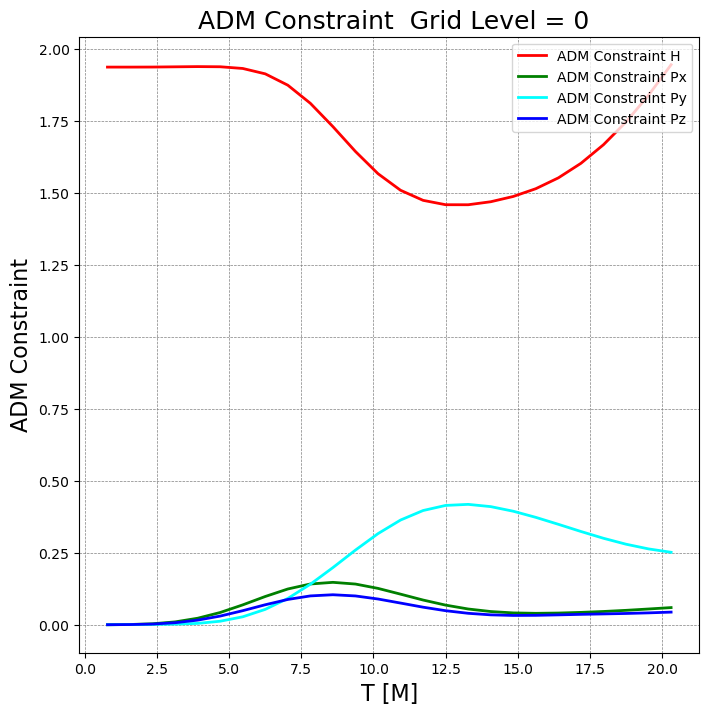

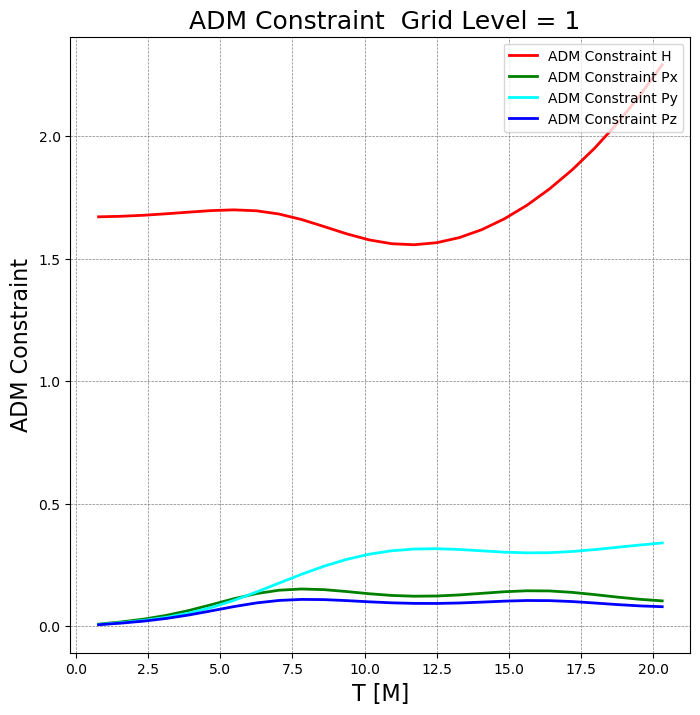

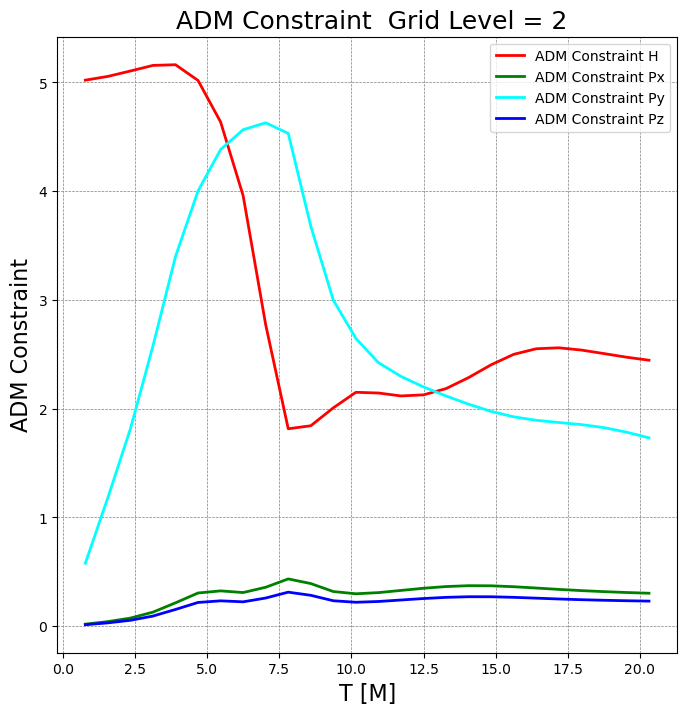

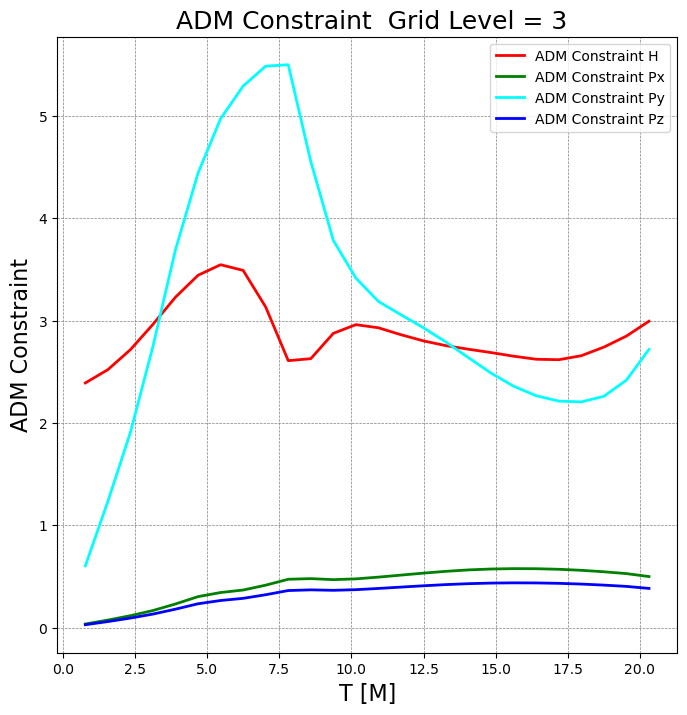

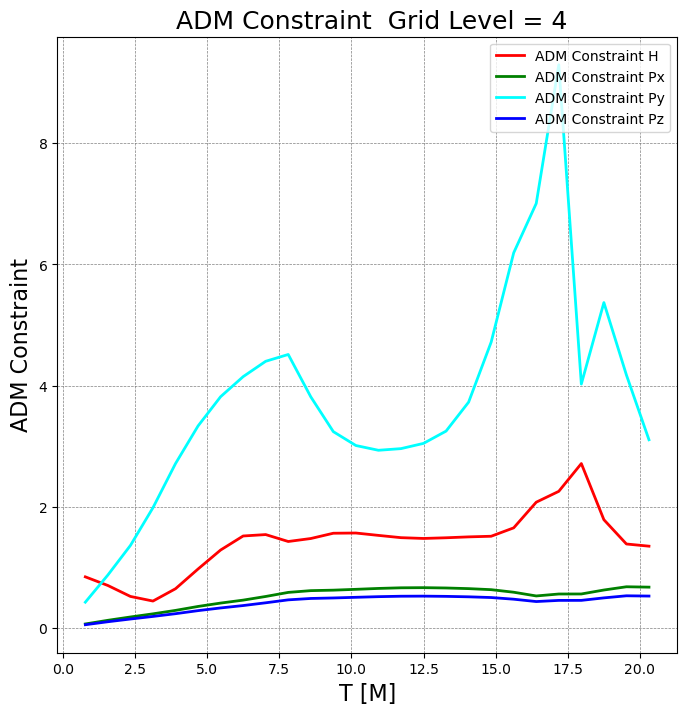

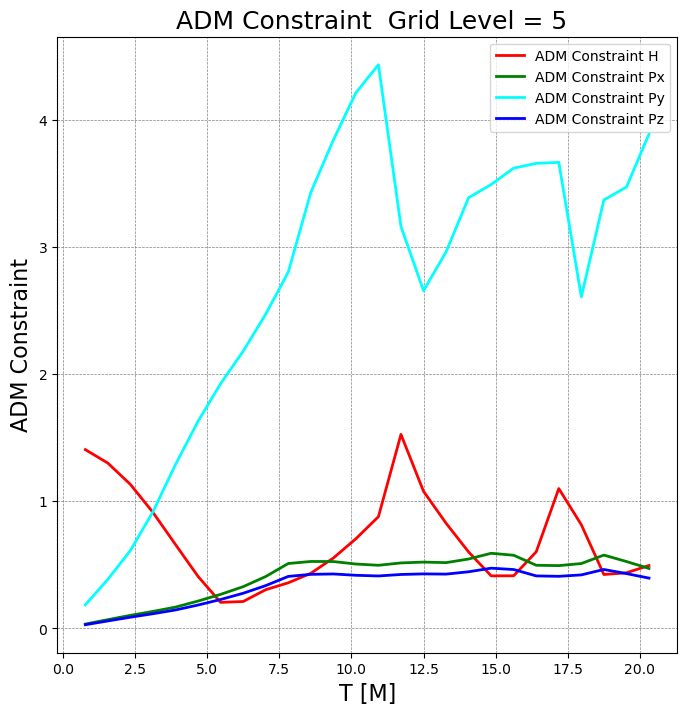

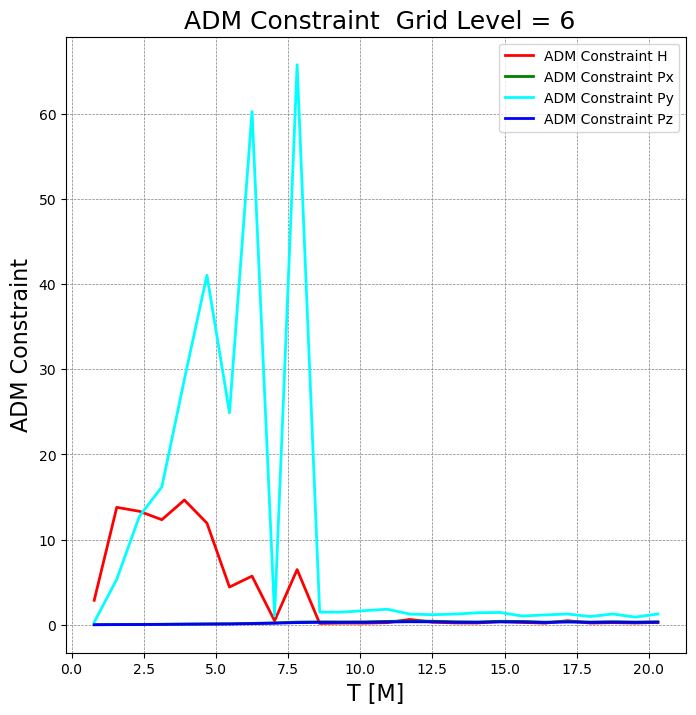

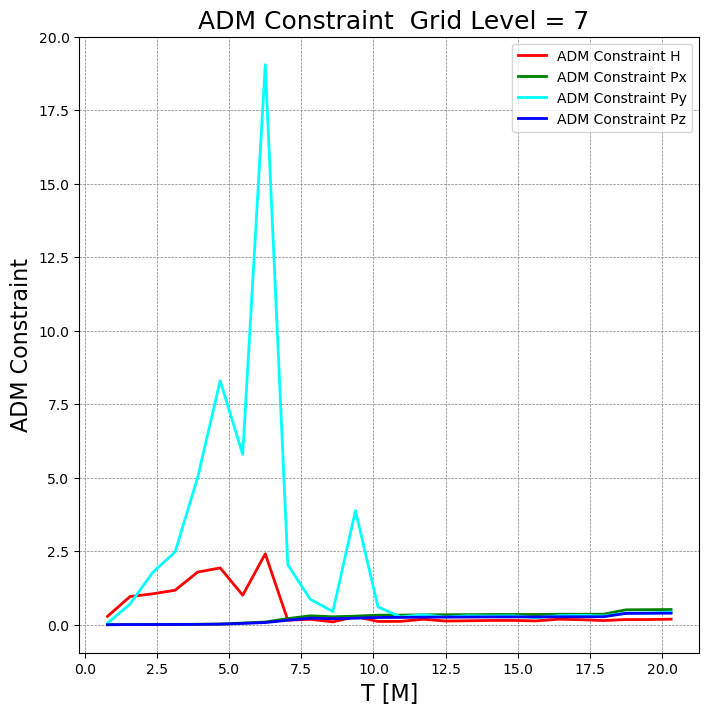

In [18]:

##################################################################
##  对 AMSS-NCKU 程序运行结果进行画图
##################################################################

import plot_xiaoqu
import plot_GW_strain_amplitude_xiaoqu
import generate_video_xiaoqu

## 屏幕输出开始画图
print_information.print_begin_plot( input_language )

## 画出黑洞轨迹图
plot_xiaoqu.generate_puncture_orbit_plot(   input_language, binary_results_directory, figure_directory )
plot_xiaoqu.generate_puncture_orbit_plot3D( input_language, binary_results_directory, figure_directory )

## 画出黑洞间距随时间的变化图
plot_xiaoqu.generate_puncture_distence_plot( input_language, binary_results_directory, figure_directory )

## 画出引力波波形图
for i in range(input_data.Detector_Number):
    plot_xiaoqu.generate_gravitational_wave_psi4_plot( input_language,binary_results_directory, figure_directory, i )
    plot_GW_strain_amplitude_xiaoqu.generate_gravitational_wave_amplitude_plot( input_language, binary_results_directory, figure_directory, i )

## 画出时空 ADM 质量的变化图
for i in range(input_data.Detector_Number):
    plot_xiaoqu.generate_ADMmass_plot( input_language, binary_results_directory, figure_directory, i )

## 画出哈密顿约束违反性况的变化图
for i in range(input_data.grid_level):
    plot_xiaoqu.generate_constraint_check_plot( input_language, binary_results_directory, figure_directory, i )

## 对储存的二进制数据画出图像
plot_xiaoqu.generate_binary_data_plot( input_language, binary_results_directory, figure_directory )

## 对储存的二进制数据生成视频
generate_video_xiaoqu.generate_binary_data_video( input_language, figure_directory, vedio_directory )


##################################################################
## 屏幕输出程序结束
##################################################################

print_information.print_program_end( input_language )


### 谢谢您的使用 